
Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

#### Import packages


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations
import os
import sys
from pathlib import Path
from typing import List, Any, Dict
import numpy as np
import pandas as pd

import shutil
import time
from datetime import datetime

#concurrent/parallel processing
from joblib import Parallel, delayed  # from functools import partial #for specific type of parallel deployment

#load preprocess specific functions
import notebook_setup
info = notebook_setup.setup()
from run_manifest import create_run_manifest, update_run_database
from config_preprocessing import load_config
from analysis_config_loader import load_analysis_config  # new import, personal config 

preprocess_func_folder = Path(info["repo_root"]) / "preprocess_functions"
sys.path.append(str(preprocess_func_folder)) #add preprocess_functions folder to path to load modules
from trial_detection import return_trial_num_at_frame, build_phase_masks, get_trial_stage_map, get_inRS_isError
from shuffle_methods import random_roll_columns_numba, random_roll_columns_fast, create_shuffled_df_optimized, random_roll_columns, get_mean_postoutcome_stage_activity
from detect_cell_enrichment import get_cell_stage_enrichment, get_cell_ensemble_info_per_subject
from matlab_obj_to_python import load_matlab_object, check_corrupted_files, truncate_post_outcome_to_15s, label_frame_sections_df, add_task_stage_to_raster_df

# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


#### Define file config variables and analysis parameters ####

In [3]:
# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)

#import local yaml for env preset variables
config_path = Path(r"analysis_config.yaml")  # adjust as needed
analysis_config = load_analysis_config(config_path)
stage_names = analysis_config.task_phase_names
print(analysis_config)

# Load general file configuration
config = load_config('config.yaml')
data_type = config['data']['data_type_used']
preprocessing = config['preprocessing']
shuffle_cfg = config['shuffles']
print(config)

# Create unique run ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
START_TIME = time.time()
print(f"Run ID: {RUN_ID}, Started: {datetime.now()}")

# Create output directory with run ID
results_dir = config['data']['results_dir']
run_output_dir = results_dir / 'shuffles' / f"shuffle_run_{RUN_ID}"
run_output_dir.mkdir(parents=True, exist_ok=True)

#set data location
data_dir = config['data']['data_dir']
source_dataset_location= config['data']['source_dataset_location']

#hardcoded/old links for checking
hardcode_results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")
hardcode_data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')
hardcode_source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19") #source dataset location has files created 10-26-2024

#print config paths for verification
print(f"\nFolders used in run ID: {RUN_ID}")
print(f"Results dir: {results_dir}")
print(f"Data dir: {data_dir}")
print(f"Source dataset location: {source_dataset_location}")

# Copy config to output directory for reference
shutil.copy('config.yaml', run_output_dir / 'config_used.yaml')

AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_thresh=2.5, final_thresh2=12.5, final_thresh3=20, final_thresh4_abs=0.01, drop_low_value_peak_events=False, drop_low_act_cell_in_dataset_obj=False, low_act_thresh_in_obj_init=0.005, cutoff_filter='bimodality', peak_event_cutoff_per

WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results/shuffles/shuffle_run_20251207_111203/config_used.yaml')

In [4]:
#set parameters
data_types = ['raster', 'dff']
data_type_used = data_types[1] #OR, 'dff'
run_activity_enrichment = True
#normalization
normalize = config['preprocessing']['normalization']
if data_type_used== 'raster':
    normalize = 'none'
print(f"Applying normalization: {normalize} on {data_type_used} data")


Applying normalization: baseline_zscore on dff data


In [5]:
#get all dataset names
content_names = [f for f in source_dataset_location.glob('**/*') if "object" in f.name] #verify you are using the correct number of dataset 
print(f"Found {len(content_names)} files in {source_dataset_location}")
assert len(content_names) == 35, "Number of datasets does not match expected"
# Load all files with error handling
loaded_objects = []
failed_files = []

for num, file in enumerate(content_names):
    obj = load_matlab_object(file)
    if obj is None:
        failed_files.append(file.name)
    else:
        loaded_objects.append(obj)
        print(f"Loading file {num}/{len(content_names)}: {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames. {obj['dff'].shape} temporal weights ")
print(f"\n SUMMARY: Successfully loaded {len(loaded_objects)}/{len(content_names)} files")
if failed_files: check_corrupted_files(loaded_objects, failed_files)

Found 35 files in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19
Loading file 0/35: 10_3_HET_RS1: 150415 cells × 136 frames. (150415, 136) temporal weights 
Loading file 1/35: 10_3_HET_RS2: 97940 cells × 168 frames. (97940, 168) temporal weights 
Loading file 2/35: 10_3_HET_RS3: 108794 cells × 157 frames. (108794, 157) temporal weights 
Loading file 3/35: 13_3_HET_RS1: 191533 cells × 160 frames. (191533, 160) temporal weights 
Loading file 4/35: 13_3_HET_RS2: 108651 cells × 145 frames. (108651, 145) temporal weights 
Loading file 5/35: 13_3_HET_RS3: 128277 cells × 147 frames. (128277, 147) temporal weights 
Loading file 6/35: 13_4_WT_RS1: 153831 cells × 183 frames. (153831, 183) temporal weights 
Loading file 7/35: 13_4_WT_RS2: 106245 cells × 171 frames. (106245, 171) temporal weights 
Loading file 8/35: 13_5_HET_RS1: 229350 cells × 120 frames. (229350, 120) temporal weights 
Loading file 9/35: 13_5_HET_RS2: 141283 cel

#### Extract and Transform Matlab Objects into stage-labeled dataframes

In [6]:
from preprocessing_utils import dataset_obj_to_df, transform_all_datasets, get_intercol_corrs, read_shuffle_parquet_from_folder, pivot_trial_windows, extract_trial_windows, create_subject_trial_tseries_df
### testing
test_df = dataset_obj_to_df(loaded_objects[0],config, analysis_config,  datatype = 'raster', normalize = 'none') #test 1 dataset
print(test_df.info())
print(test_df.sample())

 Dropping 15 cells w. 0 activity: ['cell_2', 'cell_7', 'cell_8', 'cell_18', 'cell_27', 'cell_31', 'cell_36', 'cell_44', 'cell_59', 'cell_68', 'cell_74', 'cell_80', 'cell_103', 'cell_108', 'cell_121']
Processed raster of 10_3_HET_RS1: 163651520 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 135487 entries, frame_14928 to frame_150414
Columns: 132 entries, cell_1 to truncated_post
dtypes: Int16(1), Sparse[int32, 0](121), bool(2), int32(1), object(7)
memory usage: 16.4+ MB
None
             cell_1  cell_3  cell_4  cell_5  cell_6  cell_9  cell_10  cell_11  \
frame_46745       0       0       0       0       0       0        0        0   

             cell_12  cell_13  ...  normalized  datatype  subject_name  geno  \
frame_46745        0        0  ...        none    raster  10_3_HET_RS1   HET   

             session  drop_inactive_cells  trial_num  task_stage  \
frame_46745      RS1                 True         10     Late_IA   

             trial_section  truncated_post  
frame_4674

<Figure size 960x720 with 0 Axes>

In [7]:
loaded_objects[0].keys()

dict_keys(['name', 'geno', 'session', 'geno_day', 'raster', 'deduplicated', 'good_cells', 'labels', 'dff', 'spatial_weights', 'temporal_weights', 'user_labels', 'subject_name'])

In [8]:
# Loop over imported subject rasters and create pandas DataFrames
raster_dataframes= transform_all_datasets(loaded_objects,config, analysis_config, datatype = data_type_used, normalize = normalize)

 Dropping 0 cells w. 0 activity: []
Processed dff of 10_3_HET_RS1: 81825760 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 10_3_HET_RS2: 65815680 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 10_3_HET_RS3: 68322632 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 13_3_HET_RS1: 122581120 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 13_3_HET_RS2: 63017580 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 13_3_HET_RS3: 75426876 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 13_4_WT_RS1: 112604292 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 13_4_WT_RS2: 72671580 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 13_5_HET_RS1: 110088000 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 13_5_HET_RS2: 70641500 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 13_5_HET_RS3: 50825380 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 13_6_WT_RS1: 203608028 bytes
 Dropping 0 cel

#### Circular shuffle of frame labels 

In [ ]:
# Option 1: Global seed sequence across all subjects
run_shuffles = True  #set to True to run shuffles
n_shuf_per_subject = config['shuffles']['n_shuffles_per_subject'] #default = 5000
n_shuf_per_subject = 10000
## Configuration #200 minutes for 5000 shuffles/subject on 14 cores
n_jobs=  config['shuffles']['n_cores'] -2 #base =  psutil.cpu_count(logical=False)-2  #leave 2 cores free
base_seed = config['shuffles']['base_seed'] #default: 42
n_subjects = len(raster_dataframes)

print(f"Total subjects: {n_subjects}, Shuffles per subject: {n_shuf_per_subject}")
print(f"Total shuffles to create: {n_subjects * n_shuf_per_subject}") 
#spikes- shuffles to create: 175000 is ~ 200 min 
# #dff- 5000 shuff is ~90 min #10,000 shuff is ~190 min

Total subjects: 35, Shuffles per subject: 10000
Total shuffles to create: 350000


In [10]:
from preprocess_functions.shuffle_methods import prepare_shuffle_data, create_shuffled_df_preconverted

#set shuffle storage data folder
run_output_folder = results_dir / Path(f"{data_type_used}_{normalize}_norm_ensemble_detection_{datetime.now().strftime('%d-%b-%Y')}_{n_shuf_per_subject} shuffles")
print(f" saving to {run_output_folder}")
run_output_folder.mkdir(parents=True, exist_ok=True)
shuffle_storage_folder = run_output_folder/ Path(f"shuffled_dfs_{n_shuf_per_subject}_per_subject")
print(f"storing shuffles in {shuffle_storage_folder}") 
shuffle_storage_folder.mkdir(parents=True, exist_ok=True)

#set RNG info 
rng_master = np.random.default_rng(base_seed) # Generate random seeds once at the start
seed_min, seed_max = 0, 2**31 # Generate N random seeds (each will be different)


## main shuffle body
all_subject_shuffles = {} # Process each subject with their allocated seed range
if run_shuffles:
    for subject_idx, (subject_name, subject_raster_df) in enumerate(raster_dataframes.items()):
        print(f"\nProcessing subject {subject_idx+1}/{n_subjects}: {subject_name}")
        cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
        subject_seeds = rng_master.integers(0,seed_max, size=n_shuf_per_subject) # Allocate unique seed range for this subject
        # Run parallel shuffles for this subject- oputputs lists
        #new desparsify func: 
        prepared_data = prepare_shuffle_data(subject_raster_df, cell_col)  # Convert once
        output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(
            delayed(create_shuffled_df_preconverted)((prepared_data, int(seed))) 
            for seed in subject_seeds
        )
        # output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(delayed(create_shuffled_df_optimized)((subject_raster_df, cell_col, int(seed))) for seed in subject_seeds)
        #concat and save files 
        all_shuffle_means = pd.concat(output_shuff).drop(0).reset_index('trial_section', drop = True)
        all_shuffle_means = all_shuffle_means.assign(**{'date_saved': datetime.now().strftime("%Y-%m-%d %H:%M"),
                                                        'n_shuffles': n_shuf_per_subject, 'subject_name': subject_name}) 
        all_subject_shuffles[subject_name] = all_shuffle_means
        all_shuffle_means.to_parquet(shuffle_storage_folder / Path(f"{subject_name}_shuffled_mean_activity.parquet"))   #save file
        print(f" Completed + saved {len(output_shuff)} shuffles")
    print(f"\nAll {n_subjects} subjects processed. Saving shuffled mean activity DFs to {shuffle_storage_folder}")        

 saving to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_10000 shuffles
storing shuffles in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_10000 shuffles\shuffled_dfs_10000_per_subject

Processing subject 1/35: 10_3_HET_RS1


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    6.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   11.1s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:   19.4s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:   30.7s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:   45.4s
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:  1.1min
[Parallel(n_jobs=12)]: Done 2426 tasks      | elapsed:  1.4min
[Parallel(n_jobs=12)]: Done 3176 tasks      | elapsed:  1.8min
[Parallel(n_jobs=12)]: Done 4026 tasks      | elapsed:  2.3min
[Parallel(n_jobs=12)]: Done 4976 tasks      | elapsed:  2.9min
[Parallel(n_jobs=12)]: Done 6026 tasks      | elapsed:  3.5min
[Parallel(n_jobs=12)]: Done 7176 tasks      | elapsed:  4.1min
[Parallel(n_jobs=12)]: Done 8426 tasks      | elapsed:  4.8min
[Parallel(n_jobs=12)]: Done 9776 tasks      | elapsed:  5.5min
[Parallel(n_jobs=12)]: Done 10000 out of 1000

 Completed + saved 10000 shuffles

Processing subject 2/35: 10_3_HET_RS2


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.7s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    3.6s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    8.2s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:   14.8s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:   23.1s
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:   33.4s
[Parallel(n_jobs=12)]: Done 2426 tasks      | elapsed:   45.7s
[Parallel(n_jobs=12)]: Done 3176 tasks      | elapsed:  1.0min
[Parallel(n_jobs=12)]: Done 4026 tasks      | elapsed:  1.3min
[Parallel(n_jobs=12)]: Done 4976 tasks      | elapsed:  1.6min
[Parallel(n_jobs=12)]: Done 6026 tasks      | elapsed:  1.9min
[Parallel(n_jobs=12)]: Done 7176 tasks      | elapsed:  2.2min
[Parallel(n_jobs=12)]: Done 8426 tasks      | elapsed:  2.6min
[Parallel(n_jobs=12)]: Done 9776 tasks      | elapsed:  3.0min
[Parallel(n_jobs=12)]: Done 10000 out of 1000

 Completed + saved 10000 shuffles

Processing subject 3/35: 10_3_HET_RS3


...

 Completed + saved 10000 shuffles

Processing subject 34/35: 9_3_HET_RS2


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    1.6s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    6.9s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:   15.7s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:   28.2s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:   44.3s
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:  1.1min
[Parallel(n_jobs=12)]: Done 2426 tasks      | elapsed:  1.5min
[Parallel(n_jobs=12)]: Done 3176 tasks      | elapsed:  1.9min
[Parallel(n_jobs=12)]: Done 4026 tasks      | elapsed:  2.4min
[Parallel(n_jobs=12)]: Done 4976 tasks      | elapsed:  3.0min
[Parallel(n_jobs=12)]: Done 6026 tasks      | elapsed:  3.6min
[Parallel(n_jobs=12)]: Done 7176 tasks      | elapsed:  4.3min
[Parallel(n_jobs=12)]: Done 8426 tasks      | elapsed:  5.0min
[Parallel(n_jobs=12)]: Done 9776 tasks      | elapsed:  5.9min
[Parallel(n_jobs=12)]: Done 10000 out of 1000

 Completed + saved 10000 shuffles

Processing subject 35/35: 9_3_HET_RS3


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    2.2s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:   11.2s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:   26.2s
[Parallel(n_jobs=12)]: Done 776 tasks      | elapsed:   47.1s
[Parallel(n_jobs=12)]: Done 1226 tasks      | elapsed:  1.2min
[Parallel(n_jobs=12)]: Done 1776 tasks      | elapsed:  1.8min
[Parallel(n_jobs=12)]: Done 2426 tasks      | elapsed:  2.4min
[Parallel(n_jobs=12)]: Done 3176 tasks      | elapsed:  3.2min
[Parallel(n_jobs=12)]: Done 4026 tasks      | elapsed:  4.0min
[Parallel(n_jobs=12)]: Done 4976 tasks      | elapsed:  5.0min
[Parallel(n_jobs=12)]: Done 6026 tasks      | elapsed:  6.0min
[Parallel(n_jobs=12)]: Done 7176 tasks      | elapsed:  7.1min
[Parallel(n_jobs=12)]: Done 8426 tasks      | elapsed:  8.4min
[Parallel(n_jobs=12)]: Done 9776 tasks      | elapsed:  9.8min
[Parallel(n_jobs=12)]: Done 10000 out of 1000

 Completed + saved 10000 shuffles

All 35 subjects processed. Saving shuffled mean activity DFs to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_10000 shuffles\shuffled_dfs_10000_per_subject


#### Extract parquet files and save run record

In [11]:
def log_shuffle_run(results_dir: Path, shuffle_storage_folder: Path, 
                    n_shuf_per_subject: int, n_subjects: int, base_seed: int) -> None:
    """Log a completed shuffle run to the run log CSV.
    Parameters:
    - results_dir: Directory containing the run log
    - shuffle_storage_folder: Folder where shuffle parquet files were saved
    - n_shuf_per_subject: Number of shuffles per subject
    - n_subjects: Number of subjects processed
    - base_seed: Random seed used
    """
    shuffle_run_log_path = results_dir / "shuffle_run_log.csv"
    run_info = {'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),'shuffle_folder': str(shuffle_storage_folder),'n_shuffles_per_subject': n_shuf_per_subject,'n_subjects': n_subjects,'base_seed': base_seed}
    # Load existing log or create new one
    if shuffle_run_log_path.exists():
        run_log_df = pd.read_csv(shuffle_run_log_path)
        run_log_df = pd.concat([run_log_df, pd.DataFrame([run_info])], ignore_index=True)
    else:
        run_log_df = pd.DataFrame([run_info])
    # Save updated log
    run_log_df.to_csv(shuffle_run_log_path, index=False)
    print(f"Saved latest shuffle run to {shuffle_run_log_path}")

def load_latest_shuffle_run(results_dir: Path, shuffle_storage_folder= None):
    """    Load shuffles from the most recent run in the log.
    Parameters: results_dir: Directory containing the run log
    (Optional) shuffle_storage_folder=
    
    Returns:
    - shuffle_storage_folder: Path to the shuffle folder
    - all_subject_shuffles: Loaded shuffle data
    - latest_run: Series with run metadata (timestamp, n_shuffles, etc.)
    
    Raises: FileNotFoundError: If no shuffle run log exists    """

    shuffle_run_log_path = results_dir / "shuffle_run_log.csv"
    if not shuffle_run_log_path.exists():
        raise FileNotFoundError(f"No shuffle run log found at {shuffle_run_log_path}")    
    # Load log and get most recent run
    run_log_df = pd.read_csv(shuffle_run_log_path)
    latest_run = run_log_df.iloc[-1]
    if shuffle_storage_folder == None:
        shuffle_storage_folder = Path(latest_run['shuffle_folder'])

    print(f"Loading shuffles from Timestamp: {latest_run['timestamp']} | {latest_run['n_shuffles_per_subject']} Shuffles")
    print(f"  Folder: {shuffle_storage_folder}")
    # Load all parquet files from that folder
    all_subject_shuffles = read_shuffle_parquet_from_folder(shuffle_storage_folder)
    return shuffle_storage_folder, all_subject_shuffles, latest_run

if run_shuffles: # After generating shuffles...
    log_shuffle_run(results_dir, shuffle_storage_folder, n_shuf_per_subject, len(raster_dataframes), base_seed)
else:
    shuffle_storage_folder, all_subject_shuffles, latest_run = load_latest_shuffle_run(results_dir)

Saved latest shuffle run to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffle_run_log.csv


#### Given shuffle array, run enrichment detection

In [12]:
#get + save all ensembles
all_ensembles = get_cell_ensemble_info_per_subject(raster_dataframes, all_subject_shuffles, n_shuf_per_subject)
ens_matrix = all_ensembles.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float)
#optional- save ensemble info as parquet
if 'data_type' not in all_ensembles.columns:# if data_type col isn't present in the ensemble matrix, add it
    all_ensembles['data_type'] = data_type_used
new_python_ens_file = run_output_folder / Path(f"{data_type_used}_postoutcome_python_ensembles_{n_shuf_per_subject}_shuff_{datetime.now().strftime('%d-%b-%Y_')}.parquet")
print(f"Saving {new_python_ens_file}")
all_ensembles.to_parquet(new_python_ens_file)

Processing subject: 10_3_HET_RS1
Processing subject: 10_3_HET_RS2
Processing subject: 10_3_HET_RS3
Processing subject: 13_3_HET_RS1


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


Processing subject: 13_3_HET_RS2
Processing subject: 13_3_HET_RS3
Processing subject: 13_4_WT_RS1
Processing subject: 13_4_WT_RS2
Processing subject: 13_5_HET_RS1
Processing subject: 13_5_HET_RS2
Processing subject: 13_5_HET_RS3
Processing subject: 13_6_WT_RS1
Processing subject: 13_6_WT_RS2
Processing subject: 13_8_HET_RS1
Processing subject: 13_8_HET_RS2
Processing subject: 13_8_HET_RS3
Processing subject: 14_2_WT_RS1
Processing subject: 14_2_WT_RS2
Processing subject: 15_1_HET_RS1
Processing subject: 15_1_HET_RS2
Processing subject: 15_1_HET_RS3
Processing subject: 5_3_WT_RS1
Processing subject: 5_3_WT_RS2
Processing subject: 6_2_WT_RS1
Processing subject: 6_2_WT_RS2
Processing subject: 7_2_WT_RS1
Processing subject: 7_4_WT_RS1
Processing subject: 7_5_WT_RS1
Processing subject: 7_5_WT_RS2
Processing subject: 7_6_HET_RS1
Processing subject: 7_6_HET_RS2
Processing subject: 7_6_HET_RS3
Processing subject: 9_3_HET_RS1
Processing subject: 9_3_HET_RS2
Processing subject: 9_3_HET_RS3
Savin

#### Within python latest shuffle run, compare within chunk stability


In [13]:
def chunk_shuffles_by_subject(all_subject_shuffles: Dict[str, pd.DataFrame], raster_dataframes: Dict[str, pd.DataFrame], chunk_size: int = 1000) -> pd.DataFrame:
    """ Chunk shuffles by subject into smaller sets for enrichment analysis.
    Inputs:
    all_subject_shuffles : Dict of subject_name to shuffled mean activity DataFrame
    raster_dataframes : Dict of subject_name to raster DataFrame
    chunk_size : number of unique seeds per chunk
    Returns: pd.DataFrame of combined enrichment results across all subject-chunks"""
    # Separate shuffles into chunks of 1000 unique seeds PER SUBJECT
    print(f"Chunking shuffles by subject (chunk_size={chunk_size})")
    chunked_ensemble_results = []
    # Loop over each subject
    for subject_name, shuffle_df in all_subject_shuffles.items():
        # Get unique seeds for THIS subject
        subject_unique_seeds = sorted(shuffle_df['shuffle_seed'].unique())
        n_seeds = len(subject_unique_seeds)
        n_chunks = n_seeds // chunk_size
        print(f"\n=== Processing subject: {subject_name}. total seeds: {n_seeds}, {n_chunks} chunks ===")
        
        # Get corresponding raster data
        subject_raster_df = raster_dataframes[subject_name]
        cell_col = [c for c in subject_raster_df.columns if c.startswith('cell_')]
        
        # Loop over chunks for this subject
        for chunk_idx in range(n_chunks):
            # Get specific seeds for this chunk
            start_idx = chunk_idx * chunk_size
            end_idx = (chunk_idx + 1) * chunk_size
            chunk_seeds = subject_unique_seeds[start_idx:end_idx]
            chunk_shuffle_df = shuffle_df[shuffle_df['shuffle_seed'].isin(chunk_seeds)] # Filter shuffles for this chunk
            # Run enrichment analysis for this subject-chunk
            chunk_ensembles = get_cell_stage_enrichment(all_shuffle_means=chunk_shuffle_df, raster_df=subject_raster_df, cell_col=cell_col,n_shuf_per_subject=len(chunk_seeds))
            # Add metadata
            chunked_ensemble_results.append(chunk_ensembles.assign(**{'subject_name': subject_name,'chunk_index': chunk_idx, 'chunk_seed_min': chunk_seeds[0],'chunk_seed_max': chunk_seeds[-1],'n_seeds_in_chunk': len(chunk_seeds)}))

    # Combine all subject-chunk results
    all_chunked_ensembles = pd.concat(chunked_ensemble_results, ignore_index=True)
    print(f"Processed {all_chunked_ensembles['subject_name'].nunique()} Subjects into {all_chunked_ensembles.shape} shaped DF")
    print(f"Chunks per subject: {all_chunked_ensembles.groupby('subject_name')['chunk_index'].max() + 1}")
    return all_chunked_ensembles

## pivot chunked ensembles activation and plot heatmap
def get_pivoted_enrichment_heatmap(all_chunked_ensembles: pd.DataFrame, pivot_values = 'enriched') -> pd.DataFrame:
    """ Pivot chunked ensemble enrichment results and plot heatmap of correlations.
    Inputs: all_chunked_ensembles : DataFrame with columns ['subject_name', 'task_stage', 'cell', 'chunk_index', 'enriched']
    Returns: Pivoted DataFrame of enrichment by chunk"""

    enriched_by_chunk = all_chunked_ensembles.pivot_table(index=['subject_name', 'task_stage', 'cell'], columns='chunk_index',values=pivot_values,aggfunc='first')
    enriched_by_chunk.columns = [f'chunk_{i}' for i in enriched_by_chunk.columns]
    enriched_by_chunk=enriched_by_chunk.reset_index()
    return enriched_by_chunk

In [14]:
all_chunked_ensembles = chunk_shuffles_by_subject(all_subject_shuffles, raster_dataframes, chunk_size=1000)

Chunking shuffles by subject (chunk_size=1000)

=== Processing subject: 10_3_HET_RS1. total seeds: 10000, 10 chunks ===

=== Processing subject: 10_3_HET_RS2. total seeds: 10000, 10 chunks ===

=== Processing subject: 10_3_HET_RS3. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_3_HET_RS1. total seeds: 10000, 10 chunks ===


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked


=== Processing subject: 13_3_HET_RS2. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_3_HET_RS3. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_4_WT_RS1. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_4_WT_RS2. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_5_HET_RS1. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_5_HET_RS2. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_5_HET_RS3. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_6_WT_RS1. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_6_WT_RS2. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_8_HET_RS1. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_8_HET_RS2. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_8_HET_RS3. total seeds: 10000, 10 chunks ===

=== Processing subject: 14_2_WT_RS1. total seeds: 10000, 10 chunks ===

=== Processing subject: 14_2_WT_RS2. total seeds: 10000

#### import raw shuffle data for DFF and spikes, to compare shuffle chunk similarity

In [15]:
spikes_shuffle_path = results_dir / Path(f"raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles/shuffled_dfs_5000_per_subject")

print(f"Loading shuffles from {spikes_shuffle_path}")
all_shuffles_spikes =  read_shuffle_parquet_from_folder(spikes_shuffle_path) # Load all parquet files from that folder
#if you are importing something that's NOT the current data type used, make sure to re-create raster dataframes for that datatype
# Loop over imported objects by subject and create pandas DataFrames, containing RASTERS
raster_dataframes_spikes = transform_all_datasets(loaded_objects, config, analysis_config, datatype = 'raster', normalize = 'none')
all_chunk_ens_spikes = chunk_shuffles_by_subject(all_shuffles_spikes, raster_dataframes_spikes, chunk_size=1000)
enriched_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes)
enriched_by_chunk_spikes.head()


Loading shuffles from C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles\shuffled_dfs_5000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run
 Dropping 15 cells w. 0 a

,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False


In [16]:
#Then, get dff ensemble output: 
dff_shuffle_path = results_dir / Path(r"dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles/shuffled_dfs_5000_per_subject")
print(f"Loading shuffles from {dff_shuffle_path}")
for parquet_file in dff_shuffle_path.glob("*.parquet"):
    print(parquet_file)


Loading shuffles from C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles\shuffled_dfs_5000_per_subject
C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles\shuffled_dfs_5000_per_subject\10_3_HET_RS1_shuffled_mean_activity.parquet
C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles\shuffled_dfs_5000_per_subject\10_3_HET_RS2_shuffled_mean_activity.parquet
C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles\shuffled_dfs_5000_per_subject\10_3_HET_RS3_shuffled_mean_activity.parquet
C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_de

In [17]:

all_shuffles_dff =  read_shuffle_parquet_from_folder(dff_shuffle_path) # Load all parquet files from that folder
#if you are importing something that's NOT the current data type used, make sure to re-create raster dataframes for that datatype
# Loop over imported objects by subject and create pandas DataFrames, containing RASTERS
raster_dataframes_dff = transform_all_datasets(loaded_objects, config, analysis_config, datatype = 'dff', normalize = 'baseline_zscore')
all_chunk_ens_dff = chunk_shuffles_by_subject(all_shuffles_dff, raster_dataframes_dff, chunk_size=1000)
enriched_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunk_ens_dff)
enriched_by_chunk_dff.head()


 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run
 Dropping 0 cells w. 0 activity: []
Processed dff of 10_3_HET_RS1: 81825760 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 10_3_HET_RS2: 65815680 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 10_3

c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(



=== Processing subject: 13_3_HET_RS2. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_3_HET_RS3. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_4_WT_RS1. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_4_WT_RS2. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_5_HET_RS1. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_5_HET_RS2. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_5_HET_RS3. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_6_WT_RS1. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_6_WT_RS2. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_8_HET_RS1. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_8_HET_RS2. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_8_HET_RS3. total seeds: 5000, 5 chunks ===

=== Processing subject: 14_2_WT_RS1. total seeds: 5000, 5 chunks ===

=== Processing subject: 14_2_WT_RS2. total seeds: 5000, 5 chunks ===

=== Process

,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False


In [18]:
all_shuffles_dff

{'10_3_HET_RS1':                           cell_1    cell_2    cell_3    cell_4    cell_5  \
 task_stage                                                                 
 Early_IA_Correct       -0.181238  2.270742 -0.231418  0.266136 -0.208593   
 Early_IA_Error          3.866526  0.629535 -0.284084 -0.459596  0.024476   
 Early_RS_Correct       -0.233365 -0.250237 -0.121678 -0.332362 -0.248208   
 Early_RS_Error         -0.232059  0.116491 -0.278082 -0.468141  0.037643   
 Late_IA                -0.232494  0.738371 -0.222590  0.301796 -0.087362   
 ...                          ...       ...       ...       ...       ...   
 Early_RS_Correct        1.633119 -0.265683 -0.284203  0.475729 -0.262263   
 Early_RS_Error         -0.226935 -0.265766  0.145556 -0.342543 -0.259204   
 Late_IA                 1.140736 -0.188227 -0.281260  0.029042  0.071505   
 Late_RS                 0.242117 -0.264928 -0.196485 -0.261452 -0.195416   
 truncated_post_outcome  0.201533  0.187196  0.029122 -0.206

#### Plot correlation of spike and dff data enrichment

In [19]:
def plot_stage_correlation_heatmaps(enrich_compared_df: pd.DataFrame, 
                                   stage_names: list, 
                                   merge_chunk_col: list,
                                   value_compared: str,
                                   axes: np.ndarray,
                                   grid_shape: tuple = (2, 3),
                                   vmin: float = 0.5,
                                   cmap: str = 'viridis') -> None:
    """Plot correlation heatmaps for each task stage on a subplot grid."""
    nrows, ncols = grid_shape
    
    for s, stage in enumerate(stage_names):
        ax = axes.flatten()[s]
        row, col = s // ncols, s % ncols
        
        # Compute and plot correlation for this stage
        stage_vals = enrich_compared_df[enrich_compared_df['task_stage'] == stage][merge_chunk_col].corr()
        sns.heatmap(stage_vals, vmin=vmin, cmap=cmap, ax=ax)
        
        # Remove ticks if not on edges
        if col != 0: ax.set_yticks([])
        if row != nrows - 1: ax.set_xticks([])
        
        ax.set_title(f"{stage.replace('_', ' ')}: {value_compared} correlations")

Figure saved: dff_vs_spikes_ensemble_membership_vector_chunkcorrs.jpg | In: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results


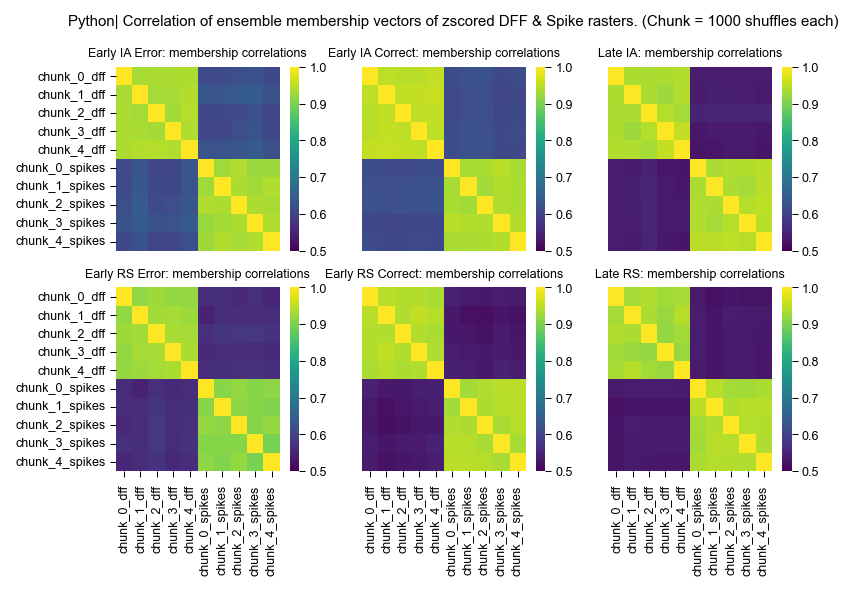

In [20]:

merged_enriched_chunks = pd.merge(enriched_by_chunk_dff, enriched_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))
# Plot correlation heatmaps
value_compared = "membership"
fig, axes = plt.subplots(2, 3, figsize=(6,3.5))
plot_stage_correlation_heatmaps(enrich_compared_df=merged_enriched_chunks, stage_names=stage_names, merge_chunk_col=[c for c in merged_enriched_chunks.columns if 'chunk_' in c], value_compared=value_compared, axes = axes)
fig.suptitle(f"Python| Correlation of ensemble {value_compared} vectors of zscored DFF & Spike rasters. (Chunk = 1000 shuffles each)")
# Save figure
fig_filename = f"dff_vs_spikes_ensemble_{value_compared}_vector_chunkcorrs.jpg"
fig.savefig(results_dir / fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved: {fig_filename} | In: {results_dir}")

Figure saved: dff_vs_spikes_ensemble_p-value_vector_chunkcorrs.jpg | In: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results


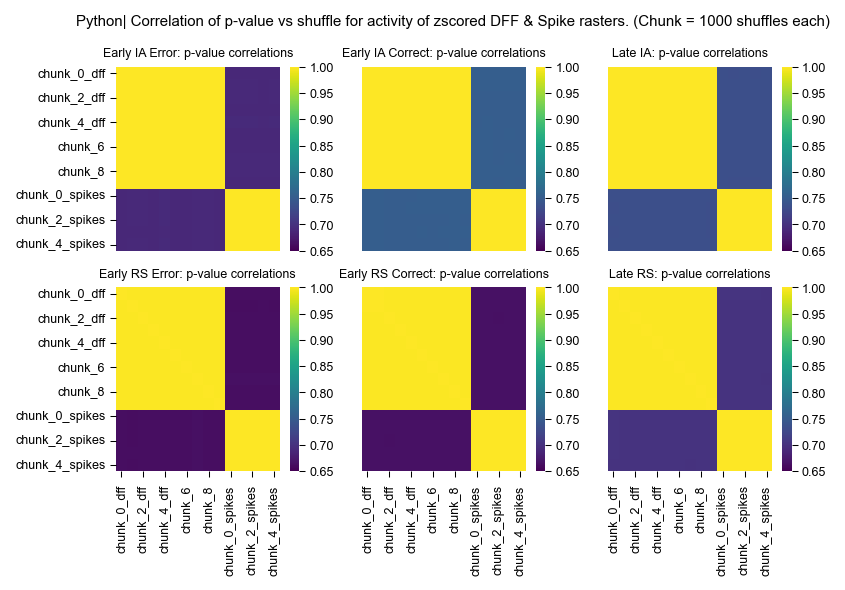

In [21]:
#use pvalue for corr 
pval_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes, pivot_values = 'percent_shuffle >= real')
pval_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunked_ensembles, pivot_values = 'percent_shuffle >= real')
merge_pval_chunks = pd.merge(pval_by_chunk_dff, pval_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))

# Plot correlation heatmaps
value_compared = "p-value"
fig, axes = plt.subplots(2, 3, figsize=(6,3.5))
plot_stage_correlation_heatmaps(enrich_compared_df=merge_pval_chunks, stage_names=stage_names, merge_chunk_col=[c for c in merge_pval_chunks.columns if 'chunk_' in c], value_compared=value_compared, vmin = 0.65, axes = axes)
fig.suptitle(f"Python| Correlation of {value_compared} vs shuffle for activity of zscored DFF & Spike rasters. (Chunk = 1000 shuffles each)")
# Save figure
fig_filename = f"dff_vs_spikes_ensemble_{value_compared}_vector_chunkcorrs.jpg"
fig.savefig(results_dir / fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved: {fig_filename} | In: {results_dir}")

#### import both DFF & spike ensemble parquets


In [22]:
# import DFF ensemble matrix 

dff_ens_path = results_dir / Path(r"dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles\dff_postoutcome_python_ensembles_5000_shuff_07-Dec-2025_.parquet")
dff_ens = pd.read_parquet(dff_ens_path)
if 'data_type' not in dff_ens.columns:
    dff_ens['data_type'] = 'dff'
print(dff_ens.info())
#get ensemble info from canon df
dff_ens.tail(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39534 entries, 0 to 39533
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               39534 non-null  object 
 1   cell                     39534 non-null  object 
 2   percentile_95            39520 non-null  float64
 3   mean                     39531 non-null  float32
 4   enriched                 39534 non-null  bool   
 5   percent_shuffle >= real  39534 non-null  float64
 6   subject_name             39534 non-null  object 
 7   neuron_id                39534 non-null  object 
 8   date_made                39534 non-null  object 
 9   n_shuffles               39534 non-null  int64  
 10  data_type                39534 non-null  object 
dtypes: bool(1), float32(1), float64(2), int64(1), object(6)
memory usage: 2.9+ MB
None


,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
39531,Late_IA,cell_215,0.708709,-0.354924,False,0.9986,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,5000,dff
39532,Late_RS,cell_215,0.746017,0.001032,False,0.3348,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,5000,dff
39533,truncated_post_outcome,cell_215,0.167036,-0.165721,False,0.9986,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,5000,dff


In [23]:
#import last spikes ensemble matrix for comparison

spikes_ens_path = results_dir / Path(r"raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles\raster_postoutcome_python_ensembles_5000_shuff_06-Dec-2025_.parquet")
spikes_ens = pd.read_parquet(spikes_ens_path)
if 'data_type' not in spikes_ens.columns:
    spikes_ens['data_type'] = 'spikes'
print(spikes_ens.info())
spikes_ens.tail(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38199 entries, 0 to 38198
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               38199 non-null  object 
 1   cell                     38199 non-null  object 
 2   percentile_95            38199 non-null  float64
 3   mean                     38199 non-null  float64
 4   enriched                 38199 non-null  bool   
 5   percent_shuffle >= real  38199 non-null  float64
 6   subject_name             38199 non-null  object 
 7   neuron_id                38199 non-null  object 
 8   date_made                38199 non-null  object 
 9   n_shuffles               38199 non-null  int64  
 10  data_type                38199 non-null  object 
dtypes: bool(1), float64(3), int64(1), object(6)
memory usage: 3.0+ MB
None


,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
38196,Late_IA,cell_215,0.024667,0.000000,False,1.0000,9_3_HET_RS3,9_3_HET_RS3-215,06-Dec-2025,5000,raster
38197,Late_RS,cell_215,0.024167,0.006667,False,0.2348,9_3_HET_RS3,9_3_HET_RS3-215,06-Dec-2025,5000,raster
38198,truncated_post_outcome,cell_215,0.008698,0.000643,False,0.9904,9_3_HET_RS3,9_3_HET_RS3-215,06-Dec-2025,5000,raster


In [24]:
## pivot both enrichment vectors, then merge
spikes_ens_matrix = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
dff_ens_matrix = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
compare_spike_dff_ens = spikes_ens_matrix.merge(dff_ens_matrix, on = 'neuron_id', suffixes=('_spikes', '_dff'))
print(compare_spike_dff_ens.info())
compare_spike_dff_ens.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5470 entries, 10_3_HET_RS1-1 to 9_3_HET_RS3-99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Early_IA_Correct_spikes        5470 non-null   float64
 1   Early_IA_Error_spikes          4441 non-null   float64
 2   Early_RS_Correct_spikes        5470 non-null   float64
 3   Early_RS_Error_spikes          5470 non-null   float64
 4   Late_IA_spikes                 5470 non-null   float64
 5   Late_RS_spikes                 5470 non-null   float64
 6   truncated_post_outcome_spikes  5470 non-null   float64
 7   Early_IA_Correct_dff           5470 non-null   float64
 8   Early_IA_Error_dff             4441 non-null   float64
 9   Early_RS_Correct_dff           5470 non-null   float64
 10  Early_RS_Error_dff             5470 non-null   float64
 11  Late_IA_dff                    5470 non-null   float64
 12  Late_RS_dff                   

task_stage,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes,truncated_post_outcome_spikes,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,truncated_post_outcome_dff
neuron_id,,,,,,,,,,,,,,
10_3_HET_RS1-1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10_3_HET_RS1-10,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10_3_HET_RS1-100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
df = compare_spike_dff_ens
correlations = {stage: df[stage+"_spikes"].corr(df[stage + '_dff']) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of enrichment vectors for DFF data vs SPIKE data: \n{corr_df}")

 Correlation of enrichment vectors for DFF data vs SPIKE data: 
                  Correlation
Early_IA_Error       0.614725
Early_IA_Correct     0.611877
Late_IA              0.540085
Early_RS_Error       0.563545
Early_RS_Correct     0.531677
Late_RS              0.527600


In [26]:
## pivot both p-value matrices, then merge
spikes_ens_pval = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
dff_ens_pval = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
compare_spike_dff_p = spikes_ens_pval.merge(dff_ens_pval, on = 'neuron_id', suffixes=('_spikes', '_dff'))
print(compare_spike_dff_p.info())
compare_spike_dff_p.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5470 entries, 10_3_HET_RS1-1 to 9_3_HET_RS3-99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Early_IA_Correct_spikes        5470 non-null   float64
 1   Early_IA_Error_spikes          5470 non-null   float64
 2   Early_RS_Correct_spikes        5470 non-null   float64
 3   Early_RS_Error_spikes          5470 non-null   float64
 4   Late_IA_spikes                 5470 non-null   float64
 5   Late_RS_spikes                 5470 non-null   float64
 6   truncated_post_outcome_spikes  5470 non-null   float64
 7   Early_IA_Correct_dff           5470 non-null   float64
 8   Early_IA_Error_dff             5470 non-null   float64
 9   Early_RS_Correct_dff           5470 non-null   float64
 10  Early_RS_Error_dff             5470 non-null   float64
 11  Late_IA_dff                    5470 non-null   float64
 12  Late_RS_dff                   

task_stage,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes,truncated_post_outcome_spikes,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,truncated_post_outcome_dff
neuron_id,,,,,,,,,,,,,,
10_3_HET_RS1-1,0.2416,0.001,1.0000,1.0,1.0,1.0,0.0150,0.3670,0.0012,0.2420,0.7520,0.5312,0.7756,0.0122
10_3_HET_RS1-10,0.2474,0.002,1.0000,1.0,1.0,1.0,0.0026,0.1514,0.0052,1.0000,0.0550,0.9648,0.7550,0.0002
10_3_HET_RS1-100,1.0000,1.000,0.4324,1.0,1.0,1.0,0.7610,0.9774,0.8332,0.6914,0.9576,0.9952,0.9886,0.9474


In [27]:
corr_df = get_intercol_corrs(compare_spike_dff_p, stage_names, suffix1="_spikes", suffix2="_dff")
print(f" Correlation of enrichment vectors for DFF data vs SPIKE data: \n{corr_df}")

 Correlation of enrichment vectors for DFF data vs SPIKE data: 
                  Correlation
Early_IA_Error       0.782634
Early_IA_Correct     0.752880
Late_IA              0.734428
Early_RS_Error       0.663589
Early_RS_Correct     0.666132
Late_RS              0.701781


#### Threshold time-series df to remove 0 

In [28]:
from preprocess_data import hyper_param_dict, bin_rotate_timeseries, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, drop_end_bins_of_trials, drop_start_bins_of_trials, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import annotate_csv, run_min_max_norm_on_timeseries


In [ ]:
#for concordance with previous code, need to label the stage col as 'task_stage_vec
stage_col = 'task_phase_vec'

def normalize_tseries_df(trial_tseries_df_raw: pd.DataFrame,
                          n_end_timebins_to_drop = config['timeseries']['n_end_timebins_to_drop'], #default = 0,
                          n_start_timebins_to_drop = config['timeseries']['n_start_timebins_to_drop'], #default = 8,
                          name_col: str = 'subject_name',
                          neuron_id_col: str = 'neuron_id',
                          ) -> pd.DataFrame:
    """ Normalize trial time-series DataFrame based on normalization type.
    Inputs:
    trial_tseries_df_raw : DataFrame with raw time-series data (ALREADY BINNED)
    hyper_param_dict : dictionary of hyperparameters
    outcome_post : DataFrame with outcome post data

    Returns: Normalized trial time-series DataFrame
    """
    #get normalization info for curr df
    normed = trial_tseries_df_raw['normalized'].unique()[0]
    if normed == 'none':
        use_min_max_norm = True 
    else:
        use_min_max_norm = False
    print(f" Data Normalization type: {normed} | Applying min-max norm? {use_min_max_norm} ")

    numeric_col = get_numeric_cols_timeseries(trial_tseries_df_raw, " to ") 
    #is min-max norm run BEFORE or AFTER bin dropping? 
    trial_tseries_df_norm = run_min_max_norm_on_timeseries(use_min_max_norm, trial_tseries_df_raw, [name_col, neuron_id_col], numeric_col, 'max_trial_val') #min_max_norm = True

    #get mean of each trial- IS this run BEFORE or AFTER norm? 
    trial_tseries_df_norm['mean_rate'] =trial_tseries_df_norm[[c for c in numeric_col if '-' not in c]].mean(axis = 1) #mean rate is post outcome only
    trial_tseries_df_norm['active_in_trial'] =trial_tseries_df_norm['mean_rate']>0

    #OPTIONAL- drop N bins from start and M bins from end of time-series
    #first, check if you're pre-truncated the data (e.g. already only sliced 3 seconds before outcome)
    neg_timebins = [c for c in numeric_col if "-" in c]
    if len(neg_timebins) <4*3+1: #if you only have 1 second or so of pre-outcome data, you've already sliced 
        n_start_timebins_to_drop = 0
    trial_tseries_df_norm = drop_end_bins_of_trials(trial_tseries_df_norm,numeric_col,  n_end_timebins_to_drop = n_end_timebins_to_drop )
    trial_tseries_df_norm = drop_start_bins_of_trials(trial_tseries_df_norm,numeric_col,  n_start_timebins_to_drop =n_start_timebins_to_drop)
    return trial_tseries_df_norm

def normalize_all_subject_tseries_dfs(raster_base_dfs: Dict[str, pd.DataFrame],
                                      config = config, 
                                      n_end_timebins_to_drop = 0,
                                      n_start_timebins_to_drop = 8,
                                      name_col: str = 'subject_name',
                                      neuron_id_col: str = 'neuron_id',
                                      ) -> pd.DataFrame:
    """ Normalize all subject trial time-series DataFrames.
    Inputs:     raster_base_dfs : Dict of subject_name to raw full recording matrix DataFrame
    optional settings for time-series normalization that equal defaults, so left un input

    Returns: concat. dataframe of subject_name to normalized trial time-series DataFrame
    """

    raster_timeseries =[]
    for name, raster_df in raster_base_dfs.items():
        print(f" Reshaping tseries of {name}: {raster_df.shape}")    
        subj_trial_tseries_df_raw= create_subject_trial_tseries_df(raster_df, dff_ens_matrix, config = config)
        subj_trial_tseries_df_norm= normalize_tseries_df(subj_trial_tseries_df_raw)
        raster_timeseries.append(subj_trial_tseries_df_norm)
    trial_tseries_df_norm = pd.concat(raster_timeseries)
    return trial_tseries_df_norm

In [30]:
trial_tseries_df_norm = normalize_all_subject_tseries_dfs(raster_dataframes, config = config)
trial_tseries_df_norm


 Reshaping tseries of 10_3_HET_RS1: (135487, 147)
Using 0 pre-outcome frames
=== COLUMN ORDERING CHECK ===
Total frame cols: 401
Pre-outcome (neg) cols: 101
Post-outcome (pos) cols: 300

First 5 neg_frames: ['-f_101', '-f_100', '-f_99', '-f_98', '-f_97']
Last 5 neg_frames: ['-f_5', '-f_4', '-f_3', '-f_2', '-f_1']

First 5 pos_frames: ['f_1', 'f_2', 'f_3', 'f_4', 'f_5']
Last 5 pos_frames: ['f_296', 'f_297', 'f_298', 'f_299', 'f_300']

=== BOUNDARY CHECK ===
Last neg frame (index 100): -f_1
First pos frame (index 101): f_1

=== BINNING BOUNDARY ===
Index 99: -f_2
Index 100: -f_1
Index 101: f_1
Index 102: f_2
Index 103: f_3
Index 104: f_4

Bin 20 (index 100-104) would contain: ['-f_1', 'f_1', 'f_2', 'f_3', 'f_4']
binning data- post. # post-outcome frames: 300 #pre-outcome frames: 101
rem_frames: 1
Merge penultimate/last bin with only 1 frame in it, then dropping last bin
 Moving numeric coluns by 0 bins
 Data Normalization type: baseline_zscore | Applying min-max norm? False 
Dropping 0 b

,trial_num,cell,subject_name,session,geno,task_phase_vec,normalized,datatype,neuron_id,day,...,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,truncated_post_outcome,any_enrichment,enriched_in_phase,mean_rate,active_in_trial
0,1,cell_1,10_3_HET_RS1,RS1,HET,Early_IA_Correct,baseline_zscore,dff,10_3_HET_RS1-1,1,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,False,-0.233417,False
1,1,cell_10,10_3_HET_RS1,RS1,HET,Early_IA_Correct,baseline_zscore,dff,10_3_HET_RS1-10,1,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,False,-0.280019,False
2,1,cell_100,10_3_HET_RS1,RS1,HET,Early_IA_Correct,baseline_zscore,dff,10_3_HET_RS1-100,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,-0.298105,False
3,1,cell_101,10_3_HET_RS1,RS1,HET,Early_IA_Correct,baseline_zscore,dff,10_3_HET_RS1-101,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,-0.434057,False
4,1,cell_102,10_3_HET_RS1,RS1,HET,Early_IA_Correct,baseline_zscore,dff,10_3_HET_RS1-102,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,False,-0.268464,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8165,38,cell_95,9_3_HET_RS3,RS3,HET,Late_RS,baseline_zscore,dff,9_3_HET_RS3-95,3,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,False,0.203617,True
8166,38,cell_96,9_3_HET_RS3,RS3,HET,Late_RS,baseline_zscore,dff,9_3_HET_RS3-96,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,-0.413252,False
8167,38,cell_97,9_3_HET_RS3,RS3,HET,Late_RS,baseline_zscore,dff,9_3_HET_RS3-97,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,-0.061609,False
8168,38,cell_98,9_3_HET_RS3,RS3,HET,Late_RS,baseline_zscore,dff,9_3_HET_RS3-98,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,-0.213799,False


In [31]:

# get mean time-series value
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")  #update post drop
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], ['subject_name', 'neuron_id','geno_day', stage_col], numeric_col) 
unit_mean_tseries


c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\preprocess_data.py:235: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  cell_avg_stage_tseries['max_val_tbin']= cell_avg_stage_tseries.loc[:,[c for c in cell_avg_stage_tseries.columns if "to" in c]].idxmax(axis = 1)


,subject_name,neuron_id,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,Early_RS_Error,Late_IA,Late_RS,truncated_post_outcome,any_enrichment,enriched_in_phase,mean_rate,active_in_trial,max_val,max_val_tbin
0,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Correct,-0.150114,-0.176919,-0.185987,-0.148819,-0.210355,-0.233417,...,0.0,0.0,0.0,1.0,1.0,False,-0.153341,False,0.419935,0.5s to 0.75s
1,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Error,-0.233417,-0.233417,-0.233417,-0.233417,-0.225664,1.144392,...,0.0,0.0,0.0,1.0,1.0,True,15.288940,True,23.836010,12.5s to 12.75s
2,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Correct,0.147034,0.030294,0.031224,-0.042703,-0.045404,-0.121671,...,0.0,0.0,0.0,1.0,1.0,False,0.224433,True,1.735852,0.25s to 0.5s
3,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Error,-0.233417,-0.233417,-0.233417,-0.233417,-0.233417,-0.233417,...,0.0,0.0,0.0,1.0,1.0,False,-0.232603,False,-0.202637,-0.5s to -0.25s
4,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Late_IA,0.250208,0.238491,0.220432,0.227306,0.211194,0.238645,...,0.0,0.0,0.0,1.0,1.0,False,-0.125501,False,0.436196,0.0s to 0.25s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33726,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_IA_Error,-0.430285,-0.465726,-0.465726,-0.465726,-0.465726,-0.465726,...,0.0,0.0,0.0,0.0,0.0,False,-0.424521,False,0.036809,1.75s to 2.0s
33727,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_RS_Correct,-0.375475,-0.465726,-0.356298,-0.372598,-0.150350,-0.244208,...,0.0,0.0,0.0,0.0,0.0,False,-0.313903,False,0.140458,8.25s to 8.5s
33728,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Early_RS_Error,0.343305,0.161700,0.098861,-0.050076,0.267671,0.294812,...,0.0,0.0,0.0,0.0,0.0,False,0.017319,True,0.893678,10.25s to 10.5s
33729,9_3_HET_RS3,9_3_HET_RS3-99,Het postCLNZ,Late_IA,-0.172721,0.018576,-0.256342,-0.193213,-0.115167,0.016896,...,0.0,0.0,0.0,0.0,0.0,False,-0.014238,True,0.989881,3.25s to 3.5s


In [32]:
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')['neuron_id'].nunique()
print(n_total_units)
print(n_total_units.sum())
#save filename with data type and date info
save_name = results_dir / Path(f"python-made_trial_timeseries_{data_type_used}_{datetime.now().strftime("%Y-%m-%d %H")}.parquet")
print(f"saving file as {save_name}")
trial_tseries_df_norm.to_parquet(save_name)


geno_day
Het CLNZ        1094
Het VEH         1094
Het postCLNZ    1177
WT CLNZ         1246
WT VEH          1192
Name: neuron_id, dtype: int64
5803
saving file as C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\python-made_trial_timeseries_dff_2025-12-07 14.parquet


#### Import canon ensemble + tseries to compare umap

In [33]:
# import canonical ensemble matrix previously created in MATLAB, used for paper #find old file- 
canonical_file = data_dir / Path(r"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")
canonical_data = pd.read_parquet(canonical_file)
print(canonical_data.info())

canonical_data

<class 'pandas.core.frame.DataFrame'>
Index: 93253 entries, 0 to 116376
Data columns (total 93 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   task_phase_vec     93253 non-null  object 
 1   IA_RS_vec          93253 non-null  object 
 2   corr_err_vec       93253 non-null  object 
 3   trial_num          93253 non-null  int64  
 4   neuron_ID          93253 non-null  int64  
 5   name               93253 non-null  object 
 6   day                93253 non-null  int32  
 7   geno               93253 non-null  object 
 8   geno_day           93253 non-null  object 
 9   -3.0s to -2.75s    93253 non-null  float64
 10  -2.75s to -2.5s    93253 non-null  float64
 11  -2.5s to -2.25s    93253 non-null  float64
 12  -2.25s to -2.0s    93253 non-null  float64
 13  -2.0s to -1.75s    93253 non-null  float64
 14  -1.75s to -1.5s    93253 non-null  float64
 15  -1.5s to -1.25s    93253 non-null  float64
 16  -1.25s to -1.0s    93253 n

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,name,day,geno,geno_day,-3.0s to -2.75s,...,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial
0,Early_IA_Correct,IA,Correct,1,1,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False
2,Early_IA_Correct,IA,Correct,1,3,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,1.0,10_3_HET_RS1-3,1.0,0.000000,False
3,Early_IA_Correct,IA,Correct,1,4,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,1.0,0.0,0.0,False,1.0,10_3_HET_RS1-4,1.0,0.000000,False
4,Early_IA_Correct,IA,Correct,1,5,10_3_HET_RS1,1,HET,Het VEH,1.0,...,0.0,0.0,0.0,0.0,False,0.0,10_3_HET_RS1-5,1.0,0.193333,True
5,Early_IA_Correct,IA,Correct,1,6,10_3_HET_RS1,1,HET,Het VEH,0.0,...,0.0,0.0,0.0,0.0,False,0.0,10_3_HET_RS1-6,1.0,0.000000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116370,Late_RS,RS,Correct,38,209,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,1.0,9_3_HET_RS3-209,1.0,0.020000,True
116373,Late_RS,RS,Correct,38,212,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,2.0,9_3_HET_RS3-212,1.0,0.030000,True
116374,Late_RS,RS,Correct,38,213,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,0.0,9_3_HET_RS3-213,1.0,0.000000,False
116375,Late_RS,RS,Correct,38,214,9_3_HET_RS3,3,HET,Het postCLNZ,0.0,...,0.0,0.0,0.0,0.0,False,0.0,9_3_HET_RS3-214,1.0,0.200000,True


In [34]:
#get canon mean unit timeseries
numeric_col_canon = get_numeric_cols_timeseries(canonical_data, " to ")  #update post drop\
canon_mean_unit_tseries  =  get_unit_mean_timeseries_by_phase(canonical_data,['trial_num'], ['name', 'neuron_ID','geno_day', stage_col], numeric_col) 
print(canon_mean_unit_tseries.groupby(by = 'geno_day')['unique_ID'].nunique())
print(canon_mean_unit_tseries.info())
canon_mean_unit_tseries


geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: unique_ID, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27768 entries, 0 to 27767
Data columns (total 94 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               27768 non-null  object 
 1   neuron_ID          27768 non-null  int64  
 2   geno_day           27768 non-null  object 
 3   task_phase_vec     27768 non-null  object 
 4   -3.0s to -2.75s    27768 non-null  float64
 5   -2.75s to -2.5s    27768 non-null  float64
 6   -2.5s to -2.25s    27768 non-null  float64
 7   -2.25s to -2.0s    27768 non-null  float64
 8   -2.0s to -1.75s    27768 non-null  float64
 9   -1.75s to -1.5s    27768 non-null  float64
 10  -1.5s to -1.25s    27768 non-null  float64
 11  -1.25s to -1.0s    27768 non-null  float64
 12  -1.0s to -0.75s    27768 non-null  float64
 13  -0.75s to -0.5s    277

,name,neuron_ID,geno_day,task_phase_vec,-3.0s to -2.75s,-2.75s to -2.5s,-2.5s to -2.25s,-2.25s to -2.0s,-2.0s to -1.75s,-1.75s to -1.5s,...,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial,max_val,max_val_tbin
0,10_3_HET_RS1,1,Het VEH,Early_IA_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
1,10_3_HET_RS1,1,Het VEH,Early_IA_Error,0.00,0.00,0.0,0.0,0.0,0.8000,...,0.0,0.0,True,1.0,10_3_HET_RS1-1,1.0,0.690000,True,1.0000,-1.5s to -1.25s
2,10_3_HET_RS1,1,Het VEH,Early_RS_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
3,10_3_HET_RS1,1,Het VEH,Early_RS_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
4,10_3_HET_RS1,1,Het VEH,Late_IA,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,1.0,10_3_HET_RS1-1,1.0,0.000000,False,0.0000,-3.0s to -2.75s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27763,9_3_HET_RS3,215,Het postCLNZ,Early_IA_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27764,9_3_HET_RS3,215,Het postCLNZ,Early_RS_Correct,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27765,9_3_HET_RS3,215,Het postCLNZ,Early_RS_Error,0.00,0.00,0.0,0.0,0.0,0.0000,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.0000,-3.0s to -2.75s
27766,9_3_HET_RS3,215,Het postCLNZ,Late_IA,0.05,0.00,0.2,0.0,0.2,0.0500,...,0.0,0.0,False,0.0,9_3_HET_RS3-215,0.8,0.000000,False,0.2000,-2.5s to -2.25s


#### UMAP on enrichment matrices

In [37]:
# UMAP analysis on ensemble matrices
import umap
from sns_plotting_config import * #import dicts containing default plot params

# # Determine first active stage for each neuron
def get_first_active_stage(row, stage_order,  non_enriched_label = 'Never'):
    """Find the first stage where neuron is enriched (value = 1)"""
    for stage in stage_order:
        if stage in row.index and row[stage] == 1:
            return stage
    return non_enriched_label

def run_dimensionality_reduction(ensemble_matrix, method='umap', metric='cosine', random_state=42, **method_kwargs):
    """Run UMAP or t-SNE on ensemble matrix. Returns (df, model)."""
    from sklearn.manifold import TSNE
    import umap
    import pandas as pd
    complete_data = ensemble_matrix.dropna()
    print(f"Shape: {ensemble_matrix.shape} → {complete_data.shape}")
    
    if method.lower() == 'umap':
        model = umap.UMAP(n_neighbors=method_kwargs.get('n_neighbors', 15), min_dist=method_kwargs.get('min_dist', 0.1), 
                          metric=metric, random_state=random_state)
    elif method.lower() == 'tsne':
        model = TSNE(perplexity=method_kwargs.get('perplexity', 30), learning_rate=method_kwargs.get('learning_rate', 200), n_iter=method_kwargs.get('n_iter', 1000),
            metric=metric, random_state=random_state)
    else:
        raise ValueError(f"method must be 'umap' or 'tsne', got '{method}'")
    
    embedding = model.fit_transform(complete_data)
    results_df = pd.DataFrame({'dim1': embedding[:, 0], 'dim2': embedding[:, 1], 'method': method.upper()}, index=complete_data.index)
    return results_df, model

In [38]:
#set umap params
value_to_project = 'mean'
metric = 'cosine'

#package spikes + dff for umap processing 
spike_umap_input = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False).drop(columns = 'truncated_post_outcome').astype(float)
dff_umap_input = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = value_to_project, fill_value = False).drop(columns = 'truncated_post_outcome').astype(float)

# Run UMAP on both spike and DFF ensemble matrices
spikes_df, umap_spikes_model = run_dimensionality_reduction( spike_umap_input, method = 'umap', n_neighbors=15, min_dist=0.2, metric=metric,random_state=42)
dff_df, umap_dff_model = run_dimensionality_reduction(dff_umap_input.replace([np.inf, -np.inf], np.nan).fillna(0), method = 'umap', n_neighbors=15, min_dist=0.2, metric=metric, random_state=42)

#join umap dfs with ensemble enrichment info
spike_cell_enrich = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
spikes_df = spikes_df.merge(spike_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)

dff_cell_enrich = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
dff_df = dff_df.merge(dff_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)


Shape: (5604, 6) → (5604, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape: (5803, 6) → (5803, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### evaluate diff of canon timeseries spikes with new psikes

In [ ]:
#new- 12/3/25- import canon timeseries + taco
#make pivot of mean activity of cell over its timeseries 
canon_spike_umap_input = canon_mean_unit_tseries.pivot_table(index = ['unique_ID'], columns = 'task_phase_vec', values = 'mean_rate', fill_value = False)
spike_mean_concat = pd.merge(canon_spike_umap_input, spike_umap_input.astype(float),  how = 'inner', left_index = True, right_index = True, suffixes=  ('_canon','_new'))
spike_mean_concat.head()

,Early_IA_Correct_canon,Early_IA_Error_canon,Early_RS_Correct_canon,Early_RS_Error_canon,Late_IA_canon,Late_RS_canon,Early_IA_Correct_new,Early_IA_Error_new,Early_RS_Correct_new,Early_RS_Error_new,Late_IA_new,Late_RS_new
10_3_HET_RS1-1,0.000000,0.69,0.000000,0.000000,0.000000,0.000,0.027500,0.646667,0.000000,0.000000,0.000000,0.000000
10_3_HET_RS1-10,0.057500,0.476667,0.000000,0.096667,0.019333,0.000,0.023333,0.646667,0.000000,0.000000,0.000000,0.000000
10_3_HET_RS1-101,0.000000,0.0,0.000000,0.000000,0.022000,0.000,0.000000,0.000000,0.000000,0.000000,0.034000,0.000000
10_3_HET_RS1-104,0.054167,0.0,0.012222,0.166667,0.084667,0.014,0.100000,0.000000,0.048889,0.133333,0.192000,0.053333
10_3_HET_RS1-107,0.000000,0.0,0.082222,0.086667,0.000667,0.004,0.000000,0.000000,0.041111,0.011667,0.094667,0.017333


       Early_IA_Error  Early_IA_Correct  Late_IA  Early_RS_Error  \
count         4749.00           4749.00  4749.00         4749.00   
mean             0.00              0.00     0.00            0.00   
std              0.05              0.05     0.03            0.04   
min             -0.43             -0.25    -0.24           -0.47   
25%              0.00             -0.01    -0.01            0.00   
50%              0.00              0.00     0.00            0.00   
75%              0.00              0.01     0.01            0.00   
max              0.35              0.30     0.24            0.53   

       Early_RS_Correct  Late_RS  
count           4749.00  4749.00  
mean               0.00     0.00  
std                0.04     0.03  
min               -0.36    -0.23  
25%                0.00    -0.00  
50%                0.00     0.00  
75%                0.00     0.00  
max                0.34     0.24  


<Axes: >

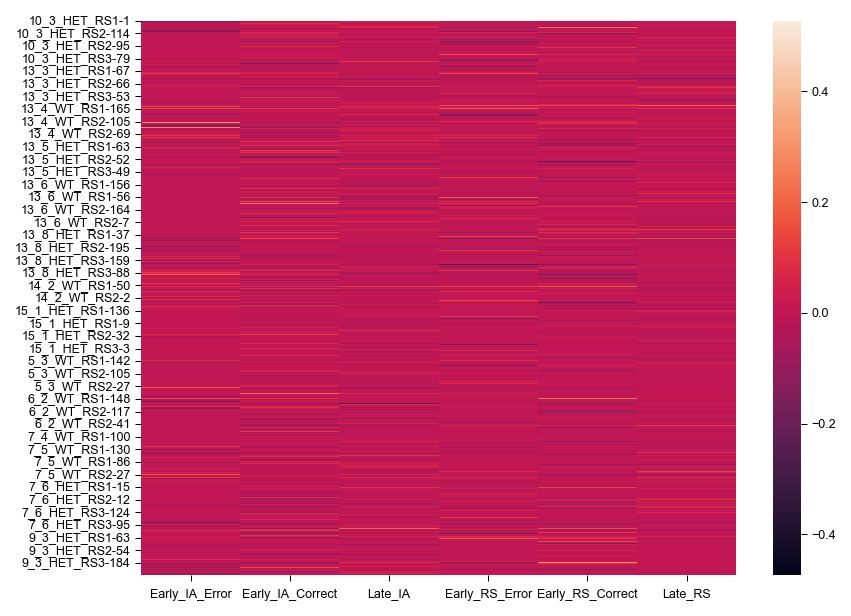

In [40]:
diff_cols = {s: (spike_mean_concat[s+"_canon"]- spike_mean_concat[s+"_new"]).astype(float) for s in stage_names}
canon_less_new_mean= pd.DataFrame(diff_cols)
#describe + plot
print(canon_less_new_mean.describe().round(2))
sns.heatmap(canon_less_new_mean.astype(float))

#### slice changed cells to further investigate

In [41]:
canon_cell_diff_bool = canon_less_new_mean != 0
canon_cell_diff_bool

,Early_IA_Error,Early_IA_Correct,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS
10_3_HET_RS1-1,True,True,False,False,False,False
10_3_HET_RS1-10,True,True,True,True,False,False
10_3_HET_RS1-101,False,False,True,False,False,False
10_3_HET_RS1-104,False,True,True,True,True,True
10_3_HET_RS1-107,False,False,True,True,True,True
...,...,...,...,...,...,...
9_3_HET_RS3-95,True,False,False,False,True,False
9_3_HET_RS3-96,True,False,True,False,True,False
9_3_HET_RS3-97,True,True,True,False,False,False
9_3_HET_RS3-98,False,True,True,False,False,False


#### Plot low-D projections: UMAP

In [42]:
canon_spikes_df, canon_umap_spikes_model = run_dimensionality_reduction( canon_spike_umap_input, method = 'umap', n_neighbors=15, min_dist=0.2, metric=metric,random_state=42)

canon_spike_cell_enrich = canon_mean_unit_tseries.groupby(by = 'unique_ID')[stage_names].first().astype(float).apply(get_first_active_stage, axis=1, stage_order=stage_names)
canon_spikes_df = canon_spikes_df.merge(canon_spike_cell_enrich.rename('first_active_stage'), left_index=True, right_index=True)
canon_spikes_df

Shape: (4776, 6) → (4776, 6)


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,dim1,dim2,method,first_active_stage
unique_ID,,,,
10_3_HET_RS1-1,14.955326,-13.225299,UMAP,Early_IA_Error
10_3_HET_RS1-10,11.758310,-0.566257,UMAP,Early_IA_Error
10_3_HET_RS1-101,-19.897745,22.507341,UMAP,Never
10_3_HET_RS1-104,7.116478,2.665500,UMAP,Late_IA
10_3_HET_RS1-107,5.358498,4.102057,UMAP,Never
...,...,...,...,...
9_3_HET_RS3-95,14.932246,-13.145504,UMAP,Never
9_3_HET_RS3-96,10.849854,-1.109410,UMAP,Never
9_3_HET_RS3-97,14.383278,-0.421262,UMAP,Early_IA_Error


c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use 

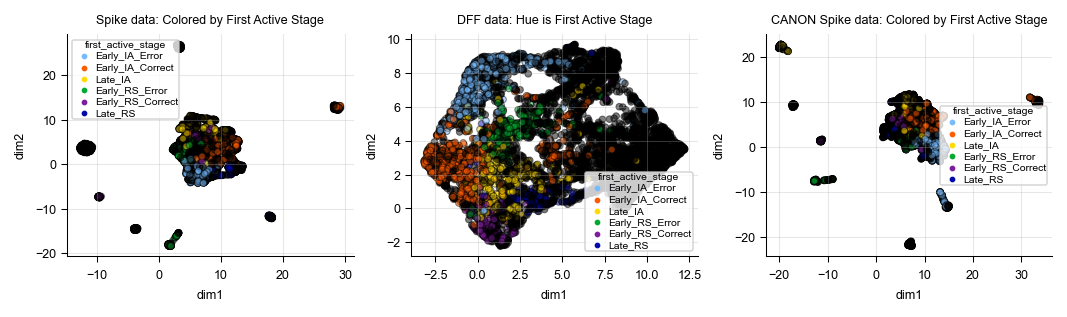

In [43]:
## PLOTTING- note that paper tSNE is projection of mean activity in stage, colored by ensemble identity
fig, axes = plt.subplots(1, 3, figsize=(7, 2), layout='constrained')
palette = [stage_palette_dict[x] for x in stage_names] + ['lightgray']
hue_col = 'first_active_stage'

# Spikes
sns.scatterplot(ax=axes[0], data=spikes_df, x='dim1', y='dim2', hue=hue_col,     palette=palette, hue_order=stage_names , s=10, alpha=0.5, edgecolor='k',linewidth=0.5, legend='full')
axes[0].set_title(f'Spike data: Colored by First Active Stage')
axes[0].grid(True, alpha=0.3)
# Spikes- CANON
sns.scatterplot(ax=axes[2], data=canon_spikes_df, x='dim1', y='dim2', hue=hue_col,     palette=palette, hue_order=stage_names , s=10, alpha=0.5, edgecolor='k',linewidth=0.5, legend='full')
axes[2].set_title(f'CANON Spike data: Colored by First Active Stage')
axes[2].grid(True, alpha=0.3)

# DFF
sns.scatterplot(ax=axes[1], data=dff_df, x='dim1', y='dim2', hue=hue_col, palette=palette, hue_order=stage_names , s=10, alpha=0.5, edgecolor='k',  linewidth=0.5, legend='full')
axes[1].set_title(f'DFF data: Hue is First Active Stage')
axes[1].grid(True, alpha=0.3)

#Final check- save manifest of config

In [44]:
subjects= unit_mean_tseries['subject_name'].unique().tolist()
enrichment_output_path = "None"
timeseries_output_path= "None"

In [45]:
# Cell: Save run manifest
runtime = time.time() - START_TIME

manifest = create_run_manifest(
    config=config,
    output_dir=run_output_dir,
    run_id=RUN_ID,
    inputs={'source_data': str(config['data']['source_dataset_location']),'n_subjects': len(subjects),},
    outputs={'shuffle_parquets': str(run_output_dir),
        'n_files': len(list(run_output_dir.glob('*.parquet'))),
        'enrichment_results': str(enrichment_output_path),
        'timeseries_results': str(timeseries_output_path),
    },
    performance={'runtime_seconds': int(runtime),'runtime_human': f"{runtime/3600:.1f} hours",'n_cores_used': config['shuffles']['n_cores'],},
    status={'success': True,'errors': [],'warnings': [],}
)

# Update central run log
run_db = update_run_database(manifest, db_path=results_dir / 'run_log.csv')
print(f"Run complete: {RUN_ID}")
print(f"Runtime: {runtime/3600:.1f} hours")
print(f"Outputs: {run_output_dir}")
print(f"Manifest: {run_output_dir / f'run_manifest_{RUN_ID}.yaml'}")

[OK] Manifest saved to: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20251207_111203\run_manifest_20251207_111203.yaml
[OK] Run database updated: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\run_log.csv
     Total runs recorded: 26
Run complete: 20251207_111203
Runtime: 3.5 hours
Outputs: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20251207_111203
Manifest: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffles\shuffle_run_20251207_111203\run_manifest_20251207_111203.yaml


#### TEMP- COMPARE TIMESERIES

LOADING DATA
CANON shape: (93253, 93)
NEW shape: (113375, 94)

Time-series columns: 72 (both files match)

CALCULATING MEAN ACTIVITY BY TASK STAGE

CANON mean activity shape: (27768, 3)
Unique neurons in CANON: 4776
Sample:
         unique_ID    task_phase_vec  mean_activity
0   10_3_HET_RS1-1  Early_IA_Correct       0.000000
1   10_3_HET_RS1-1    Early_IA_Error       0.669444
2   10_3_HET_RS1-1  Early_RS_Correct       0.000000
3   10_3_HET_RS1-1    Early_RS_Error       0.000000
4   10_3_HET_RS1-1           Late_IA       0.000000
5   10_3_HET_RS1-1           Late_RS       0.000000
6  10_3_HET_RS1-10  Early_IA_Correct       0.075000
7  10_3_HET_RS1-10    Early_IA_Error       0.397222
8  10_3_HET_RS1-10  Early_RS_Correct       0.000000
9  10_3_HET_RS1-10    Early_RS_Error       0.147222

NEW mean activity shape: (33731, 3)
Unique neurons in NEW: 5803
Sample:
         neuron_id    task_phase_vec  mean_activity
0   10_3_HET_RS1-1  Early_IA_Correct      -0.162591
1   10_3_HET_RS1-1    Early

c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)



Saved visualization to: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\timeseries_comparison.png


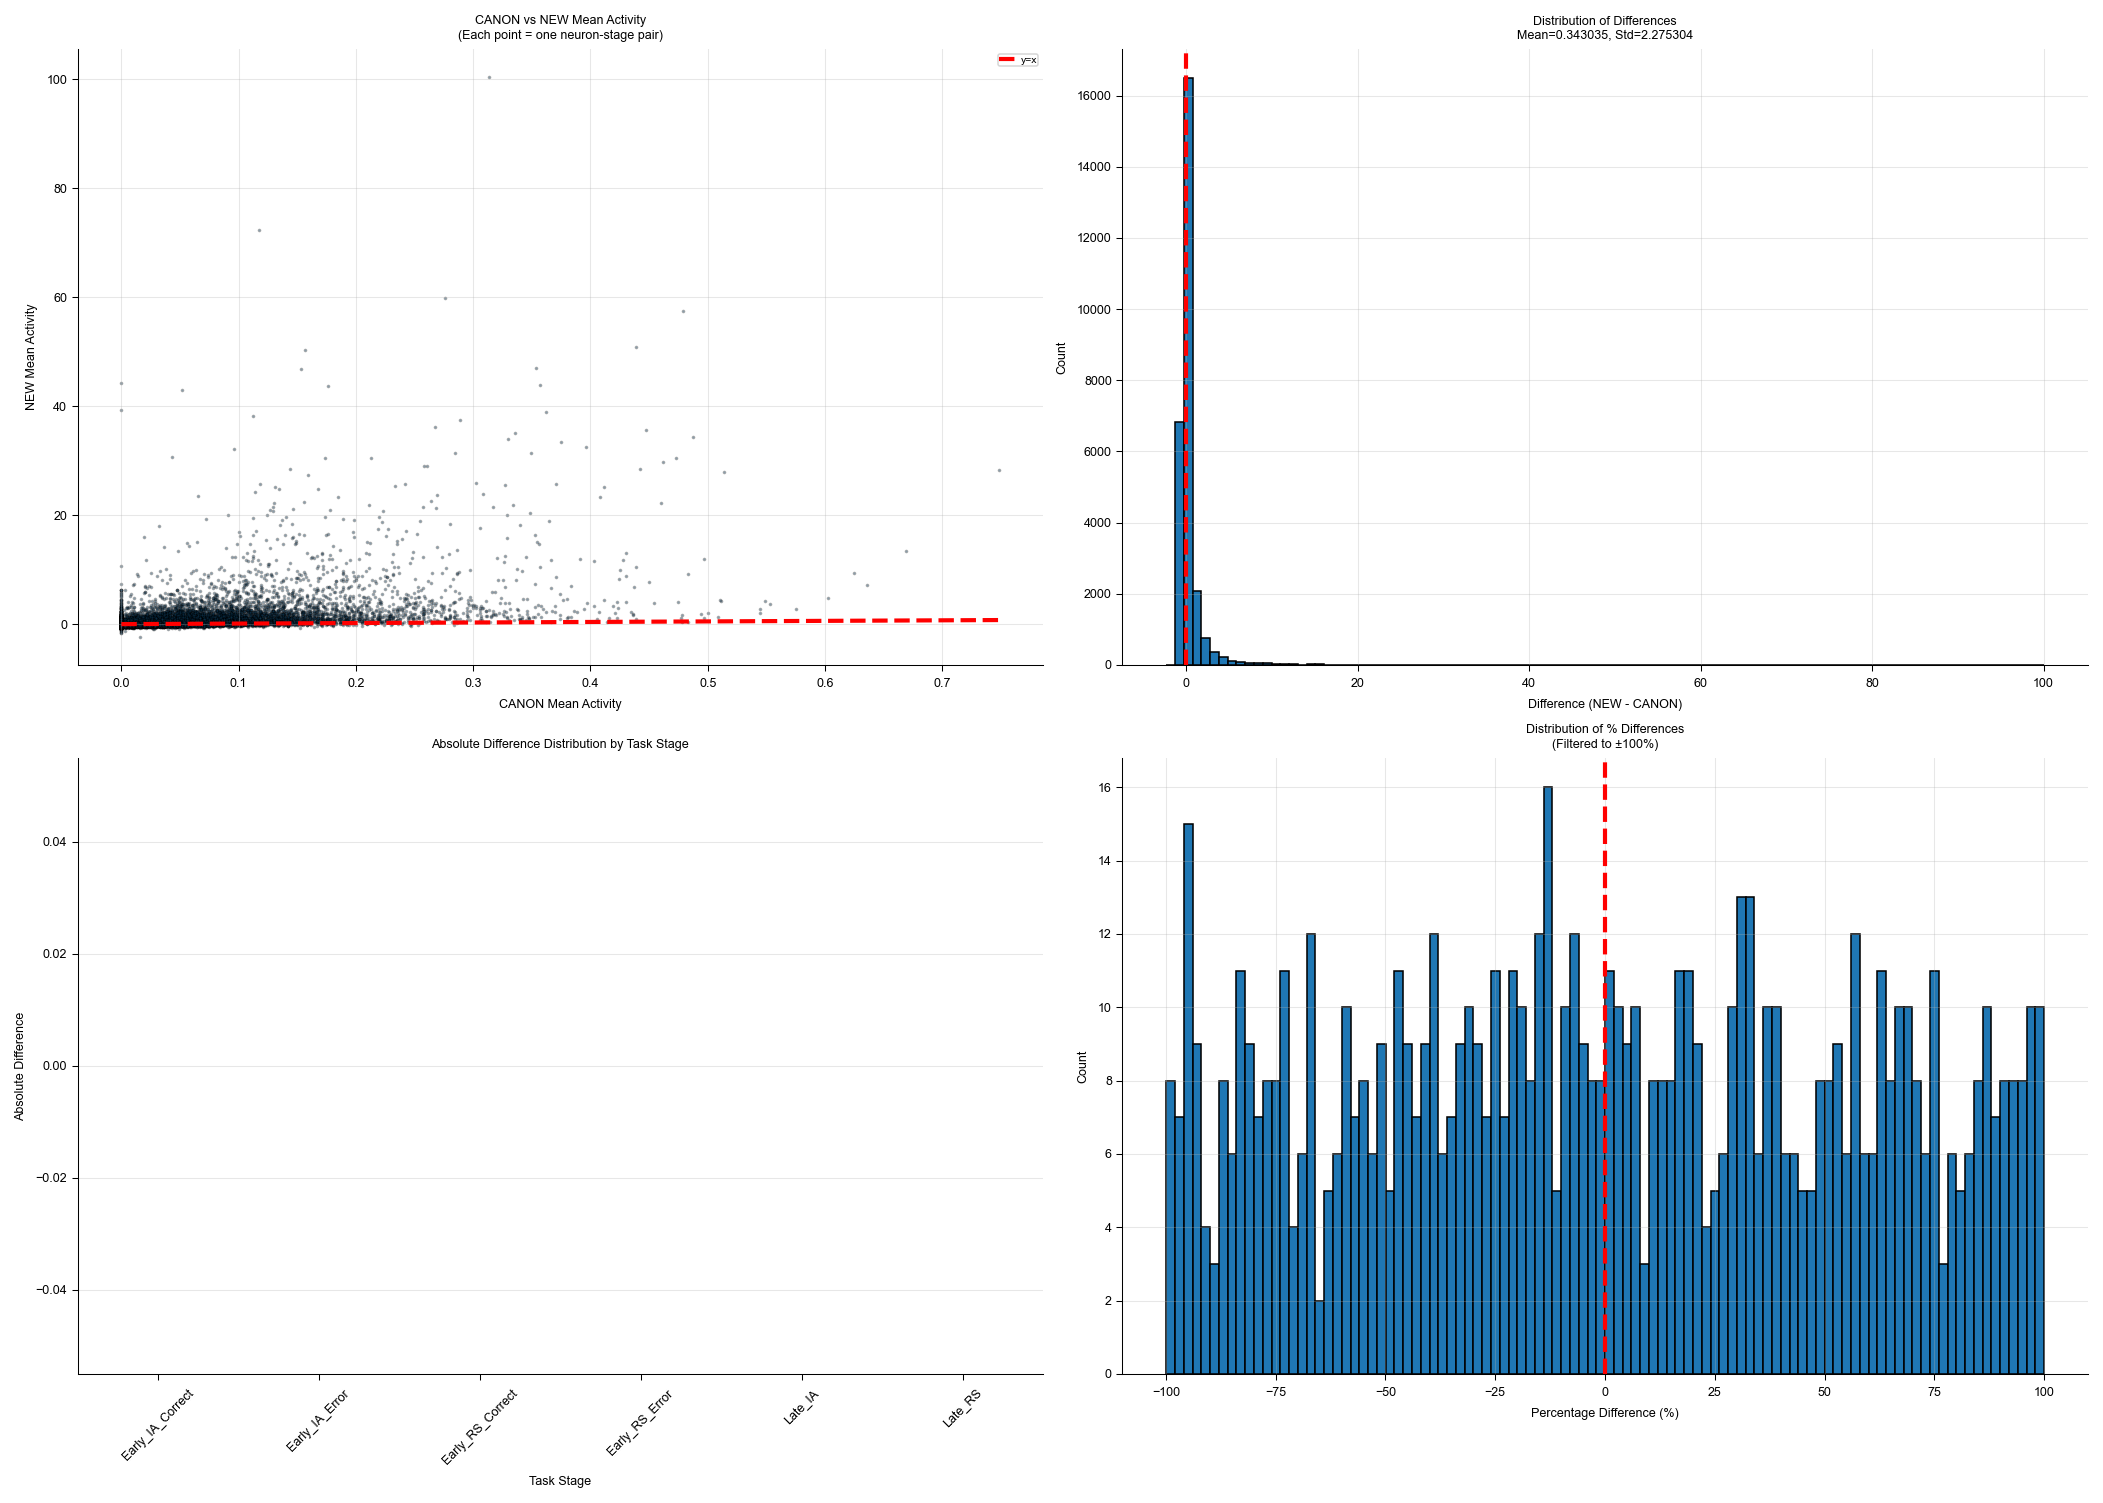


Saved detailed comparison to: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\timeseries_comparison_detailed.parquet

ANALYSIS COMPLETE

SUMMARY:
  Neurons in CANON: 4776
  Neurons in NEW: 4814
  Neurons in both: 4676
  Matched neuron-stage pairs: 27300
  Pairs with ANY difference: 4697
  Pairs with SIGNIFICANT difference: 4697


In [47]:
"""
CORRECTED Analysis - comparing matching neurons between CANON and NEW
"""

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Load data
# canon_path = data_dir / "post_outcome_main_datasets_neurons_trial activity timeseries data_10-Dec-2024_timeseries.csv"
# new_path = results_dir / "python-made_trial_timeseries_raster_2025-12-04 18.parquet"

print("="*80)
print("LOADING DATA")
print("="*80)
canon_df = pd.read_parquet(canon_path)
# Re-load the newly generated data
new_df = trial_tseries_df_norm  # Or however you reference it
# new_df = pd.read_parquet(new_path)
print(f"CANON shape: {canon_df.shape}")
print(f"NEW shape: {new_df.shape}")

# Get time-series columns
canon_ts_cols = [col for col in canon_df.columns if 's to' in col]
new_ts_cols = [col for col in new_df.columns if 's to' in col]

print(f"\nTime-series columns: {len(canon_ts_cols)} (both files match)")

# ==============================================================================
# CALCULATE MEAN ACTIVITY BY TASK STAGE FOR EACH NEURON
# ==============================================================================
print("\n" + "="*80)
print("CALCULATING MEAN ACTIVITY BY TASK STAGE")
print("="*80)

# CANON - use unique_ID (not neuron_ID!)
canon_mean_by_stage = (canon_df.groupby(['unique_ID', 'task_phase_vec'])[canon_ts_cols]
                       .mean()
                       .mean(axis=1)  # Mean across all timepoints
                       .reset_index(name='mean_activity'))

print(f"\nCANON mean activity shape: {canon_mean_by_stage.shape}")
print(f"Unique neurons in CANON: {canon_mean_by_stage['unique_ID'].nunique()}")
print(f"Sample:\n{canon_mean_by_stage.head(10)}")

# NEW
new_mean_by_stage = (new_df.groupby(['neuron_id', 'task_phase_vec'])[new_ts_cols]
                     .mean()
                     .mean(axis=1)  # Mean across all timepoints
                     .reset_index(name='mean_activity'))

print(f"\nNEW mean activity shape: {new_mean_by_stage.shape}")
print(f"Unique neurons in NEW: {new_mean_by_stage['neuron_id'].nunique()}")
print(f"Sample:\n{new_mean_by_stage.head(10)}")

# ==============================================================================
# MERGE AND COMPARE
# ==============================================================================
print("\n" + "="*80)
print("MERGING AND COMPARING MEAN ACTIVITIES")
print("="*80)

# Rename for merging
canon_mean_renamed = canon_mean_by_stage.rename(columns={
    'unique_ID': 'neuron_id',
    'task_phase_vec': 'task_stage',
    'mean_activity': 'canon_mean'
})

new_mean_renamed = new_mean_by_stage.rename(columns={
    'task_phase_vec': 'task_stage',
    'mean_activity': 'new_mean'
})

# Merge
comparison = canon_mean_renamed.merge(
    new_mean_renamed,
    on=['neuron_id', 'task_stage'],
    how='outer',
    indicator=True
)

print(f"\nMerge result shape: {comparison.shape}")
print(f"\nMerge indicator counts:")
print(comparison['_merge'].value_counts())

# Calculate difference
comparison['difference'] = comparison['new_mean'] - comparison['canon_mean']
comparison['abs_difference'] = comparison['difference'].abs()
comparison['pct_difference'] = (comparison['difference'] / comparison['canon_mean']) * 100

# ==============================================================================
# ANALYZE DIFFERENCES
# ==============================================================================
print("\n" + "="*80)
print("DIFFERENCE STATISTICS")
print("="*80)

# Filter to only matching records
matched = comparison[comparison['_merge'] == 'both'].copy()
print(f"\nMatched neuron-stage pairs: {len(matched)}")
print(f"Unique neurons in matched pairs: {matched['neuron_id'].nunique()}")

print(f"\nDifference statistics:")
print(matched[['difference', 'abs_difference', 'pct_difference']].describe())

# Find cells with largest differences
print(f"\n\nTop 20 neuron-stage pairs with largest absolute differences:")
top_diffs = matched.nlargest(20, 'abs_difference')[
    ['neuron_id', 'task_stage', 'canon_mean', 'new_mean', 'difference', 'pct_difference']
]
print(top_diffs.to_string())

# Cells with any difference
cells_with_diff = matched[matched['abs_difference'] > 1e-10]['neuron_id'].unique()
print(f"\n\nCells with ANY difference (>1e-10): {len(cells_with_diff)}")
print(f"Total unique cells in comparison: {matched['neuron_id'].nunique()}")
print(f"Percentage with differences: {len(cells_with_diff)/matched['neuron_id'].nunique()*100:.1f}%")

# Cells with significant difference (>1% or >0.01 absolute)
cells_with_sig_diff = matched[
    (matched['abs_difference'] > 0.01) | (matched['pct_difference'].abs() > 1)
]['neuron_id'].unique()
print(f"\nCells with SIGNIFICANT difference (>1% or >0.01 abs): {len(cells_with_sig_diff)}")
print(f"Percentage: {len(cells_with_sig_diff)/matched['neuron_id'].nunique()*100:.1f}%")

# By stage analysis
print(f"\n\nDifferences by task stage:")
stage_stats = matched.groupby('task_stage').agg({
    'difference': ['mean', 'std', 'min', 'max'],
    'abs_difference': ['mean', 'max'],
    'neuron_id': 'count'
})
print(stage_stats)

# Check which neurons are missing
print("\n" + "="*80)
print("MISSING NEURONS")
print("="*80)

only_canon = comparison[comparison['_merge'] == 'left_only']['neuron_id'].unique()
only_new = comparison[comparison['_merge'] == 'right_only']['neuron_id'].unique()

print(f"\nNeurons only in CANON: {len(only_canon)}")
if len(only_canon) <= 20:
    print(f"  {sorted(only_canon)}")

print(f"\nNeurons only in NEW: {len(only_new)}")
if len(only_new) <= 20:
    print(f"  {sorted(only_new)}")

# ==============================================================================
# VISUALIZATION
# ==============================================================================
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter plot: CANON vs NEW
ax = axes[0, 0]
ax.scatter(matched['canon_mean'], matched['new_mean'], alpha=0.3, s=1)
ax.plot([matched['canon_mean'].min(), matched['canon_mean'].max()],
        [matched['canon_mean'].min(), matched['canon_mean'].max()],
        'r--', lw=2, label='y=x')
ax.set_xlabel('CANON Mean Activity')
ax.set_ylabel('NEW Mean Activity')
ax.set_title('CANON vs NEW Mean Activity\n(Each point = one neuron-stage pair)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Histogram of differences
ax = axes[0, 1]
ax.hist(matched['difference'], bins=100, edgecolor='black')
ax.set_xlabel('Difference (NEW - CANON)')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of Differences\nMean={matched["difference"].mean():.6f}, Std={matched["difference"].std():.6f}')
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.grid(True, alpha=0.3)

# 3. Absolute difference by stage
ax = axes[1, 0]
stage_groups = matched.groupby('task_stage')['abs_difference']
stage_names = list(stage_groups.groups.keys())
stage_values = [stage_groups.get_group(s).values for s in stage_names]
ax.boxplot(stage_values, labels=stage_names)
ax.set_ylabel('Absolute Difference')
ax.set_xlabel('Task Stage')
ax.set_title('Absolute Difference Distribution by Task Stage')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# 4. Percentage difference distribution
ax = axes[1, 1]
# Filter out infinite and very large values for visualization
pct_diff_filtered = matched['pct_difference'][
    (matched['pct_difference'].abs() < 100) &
    (matched['pct_difference'].notna())
]
ax.hist(pct_diff_filtered, bins=100, edgecolor='black')
ax.set_xlabel('Percentage Difference (%)')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of % Differences\n(Filtered to ±100%)')
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / 'timeseries_comparison.png', dpi=150, bbox_inches='tight')
print(f"\nSaved visualization to: {results_dir / 'timeseries_comparison.png'}")
plt.show()

# Save comparison data
comparison_path = results_dir / 'timeseries_comparison_detailed.parquet'
matched.to_parquet(comparison_path)
print(f"\nSaved detailed comparison to: {comparison_path}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)
print(f"\nSUMMARY:")
print(f"  Neurons in CANON: 4776")
print(f"  Neurons in NEW: 4814")
print(f"  Neurons in both: 4676")
print(f"  Matched neuron-stage pairs: {len(matched)}")
print(f"  Pairs with ANY difference: {len(cells_with_diff)}")
print(f"  Pairs with SIGNIFICANT difference: {len(cells_with_sig_diff)}")

In [51]:
# For this neuron (13_4_WT_RS2-42) in trial 4:
# What are the RAW frame values (before binning) in the pre-outcome section?

# In the raster DataFrame (before extract_trial_windows), for trial 4:
test_subject = '13_4_WT_RS2'  # Adjust to match your subject naming
test_neuron_idx = 42  # Adjust if needed

# Get the raw raster for this subject
subject_df = raster_dataframes[test_subject]  # or whatever your dict is called

# Filter to trial 4, pre_outcome section
trial_4_pre = subject_df[(subject_df['trial_num'] == 4) & (subject_df['trial_section'] == 'pre_outcome')]

# Show the activity values for this neuron
cell_col = 'cell_42'  # or however it's named
print(f"Number of pre-outcome frames in trial 4: {trial_4_pre.shape}")
print(f"Cell activity in these frames:")
print(trial_4_pre[cell_col].values)

Number of pre-outcome frames in trial 4: (1060, 182)
Cell activity in these frames:
[0.440625  0.5444763 0.6959581 ... 3.8903673 3.9754763 4.0346527]


In [54]:
print(trial_4_pre[cell_col].shape)  # 0-indexed

(1060,)


In [55]:
# Load the original MATLAB CSV that was used to create CANON
# This is the CSV exported from MATLAB's return_section_activity_timeseries.m
# Path to the MATLAB-exported CSV
# Adjust this path based on where the file is located
matlab_csv_path = Path(r"G:\My Drive\Colab Notebooks\Sohal Lab Datasets\time-series including WT CLNZ dataset\11-Dec-2024_event_fixed_stage_labels Dataset Source\post_outcome_main_datasets_neurons_trial activity timeseries data_10-Dec-2024_timeseries.csv")

# Or if it's local:
matlab_csv_path = data_dir / Path(r"post_outcome_main_datasets_neurons_trial activity timeseries data_10-Dec-2024_timeseries.csv")
matlab_csv = pd.read_csv(matlab_csv_path)
print(f"Loading MATLAB CSV from: {matlab_csv_path}")
print(f"File exists: {matlab_csv_path.exists()}")


C:\Users\13car\AppData\Local\Temp\ipykernel_21972\1782868539.py:9: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  matlab_csv = pd.read_csv(matlab_csv_path)


Loading MATLAB CSV from: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\post_outcome_main_datasets_neurons_trial activity timeseries data_10-Dec-2024_timeseries.csv
File exists: True


In [56]:
# 1. Check if any cells were dropped in Python
subject_df = raster_dataframes[test_subject]
cell_cols = [c for c in subject_df.columns if c.startswith('cell_')]
print(f"Cells in Python raster: {len(cell_cols)}")
print(f"Cell numbers: {[int(c.replace('cell_','')) for c in cell_cols[:10]]}...")  # First 10

# 2. Check how many neurons MATLAB has for this subject
matlab_neurons = matlab_csv[matlab_csv['name'] == test_subject]['neuron_ID'].unique()
print(f"\nNeurons in MATLAB CSV: {len(matlab_neurons)}")
print(f"Neuron IDs: {sorted(matlab_neurons)[:10]}...")  # First 10

# 3. Check if cell_42 exists in Python
if 'cell_42' in cell_cols:
    print(f"\ncell_42 exists in Python: YES")
else:
    print(f"\ncell_42 exists in Python: NO - it may have been dropped!")
    
# 4. Check if neuron_ID 42 exists in MATLAB
if 42 in matlab_neurons:
    print(f"neuron_ID 42 exists in MATLAB: YES")
else:
    print(f"neuron_ID 42 exists in MATLAB: NO")

# 5. CRITICAL: Check if the neuron_id in the final NEW dataframe is correct
# After pivoting, the neuron_id is created as: subject_name + '-' + cell_number
new_neuron_ids = new_df[new_df['neuron_id'].str.startswith('13_4_WT_RS2')]['neuron_id'].unique()
print(f"\nNeuron IDs in NEW dataset for this subject: {len(new_neuron_ids)}")
print(f"Does '13_4_WT_RS2-42' exist? {'13_4_WT_RS2-42' in new_neuron_ids}")

# 6. Check if CANON uses 'unique_ID' that matches
canon_neuron_ids = canon_df[canon_df['unique_ID'].str.startswith('13_4_WT_RS2')]['unique_ID'].unique()
print(f"\nNeuron IDs in CANON for this subject: {len(canon_neuron_ids)}")
print(f"Does '13_4_WT_RS2-42' exist? {'13_4_WT_RS2-42' in canon_neuron_ids}")

Cells in Python raster: 171
Cell numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...

Neurons in MATLAB CSV: 171
Neuron IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]...

cell_42 exists in Python: YES
neuron_ID 42 exists in MATLAB: YES

Neuron IDs in NEW dataset for this subject: 171
Does '13_4_WT_RS2-42' exist? True

Neuron IDs in CANON for this subject: 147
Does '13_4_WT_RS2-42' exist? True


In [57]:
# For trial 4, check POST-OUTCOME activity at the raw level

# MATLAB CSV: Get post-outcome frame values
matlab_row = matlab_csv[(matlab_csv['name'] == test_subject) & 
                        (matlab_csv['neuron_ID'] == 42) &
                        (matlab_csv['trial_num'] == 4)]

post_frame_cols = sorted([col for col in matlab_csv.columns if col.startswith('f_') and not col.startswith('-f_')],
                         key=lambda x: int(x.split('_')[1]))

matlab_post_values = matlab_row[post_frame_cols[:60]].values[0]  # First 60 post frames

print("MATLAB CSV post-outcome (first 60 frames):")
print(matlab_post_values)
print(f"Non-zero: {(matlab_post_values > 0).sum()}")

# Python raw: Get post-outcome frame values for trial 4
trial_4_post = subject_df[(subject_df['trial_num'] == 4) & 
                           (subject_df['trial_section'] == 'post_outcome')]

python_post_values = trial_4_post['cell_42'].values[:60]  # First 60 post frames

print("\nPython raw post-outcome (first 60 frames):")
print(python_post_values)
print(f"Non-zero: {(python_post_values > 0).sum()}")

# Compare
print(f"\nValues match: {np.array_equal(matlab_post_values, python_post_values)}")
if not np.array_equal(matlab_post_values, python_post_values):
    print(f"Max difference: {np.max(np.abs(matlab_post_values - python_post_values))}")

MATLAB CSV post-outcome (first 60 frames):
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Non-zero: 60

Python raw post-outcome (first 60 frames):
[4.0092    4.0685964 4.183536  4.411362  4.51888   4.388307  4.234308
 4.1898875 4.2199674 4.2204056 4.2417626 4.1841564 4.151492  4.049832
 3.995064  4.0248594 4.094132  4.063157  3.9373868 3.8501334 3.9359024
 3.9466558 3.8327875 3.7428439 3.7229447 3.768011  3.9802117 4.073017
 4.035191  3.9271085 3.7176816 3.5123096 3.523936  3.5777206 3.512185
 3.3590794 3.2373607 3.1707242 3.3167808 3.519741  3.43289   3.1387215
 3.0794413 3.1956484 3.1333885 2.756369  2.5667229 2.6612136 2.6885893
 2.514236  2.4163332 2.422061  2.3714938 2.2489047 2.2092562 2.3894315
 2.575581  2.5173664 2.3643794 2.250376 ]
Non-zero: 60

Values match: False
Max difference: 3.5188798904418945


In [58]:
test_neuron = '13_4_WT_RS2-42'
test_stage = 'Early_IA_Error'
test_trial = 4

# Get NEW values with the updated extraction
new_row = new_df[(new_df['neuron_id'] == test_neuron) & 
                  (new_df['task_phase_vec'] == test_stage) &
                  (new_df['trial_num'] == test_trial)]

canon_row = canon_df[(canon_df['unique_ID'] == test_neuron) & 
                      (canon_df['task_phase_vec'] == test_stage) &
                      (canon_df['trial_num'] == test_trial)]

print("NEW pre-outcome bins (first 12):")
print(f"{new_ts_cols[:12]}")
print(new_row[new_ts_cols[:12]].values[0])

print("\nCANON pre-outcome bins (first 12):")
print(f"{canon_ts_cols[:12]}")
print(canon_row[canon_ts_cols[:12]].values[0])

print(f"\nValues match: {np.allclose(canon_row[canon_ts_cols].values, new_row[new_ts_cols].values, equal_nan=True)}")

NEW pre-outcome bins (first 12):
['-3.0s to -2.75s', '-2.75s to -2.5s', '-2.5s to -2.25s', '-2.25s to -2.0s', '-2.0s to -1.75s', '-1.75s to -1.5s', '-1.5s to -1.25s', '-1.25s to -1.0s', '-1.0s to -0.75s', '-0.75s to -0.5s', '-0.5s to -0.25s', '-0.25s to -0.0s']
[1.6818721 1.5210743 1.2928549 1.3920052 1.9682496 2.6911013 3.035998
 3.296268  3.4216697 3.7139823 3.7381866 3.8667755]

CANON pre-outcome bins (first 12):
['-3.0s to -2.75s', '-2.75s to -2.5s', '-2.5s to -2.25s', '-2.25s to -2.0s', '-2.0s to -1.75s', '-1.75s to -1.5s', '-1.5s to -1.25s', '-1.25s to -1.0s', '-1.0s to -0.75s', '-0.75s to -0.5s', '-0.5s to -0.25s', '-0.25s to -0.0s']
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Values match: False


#### DIagnostic notebook cell import (from md)

In [59]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load both datasets
data_dir = Path(r"c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data")
results_dir = Path(r"c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")

canon_path = data_dir / "Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
new_path = results_dir / "python-made_trial_timeseries_raster_2025-12-04 15.parquet"

print("Loading datasets...")
canon_df = pd.read_parquet(canon_path)
new_df = pd.read_parquet(new_path)

# Get time-series columns
canon_ts_cols = [c for c in canon_df.columns if 's to ' in str(c)]
new_ts_cols = [c for c in new_df.columns if 's to ' in str(c)]

print(f"CANON shape: {canon_df.shape}, time-series bins: {len(canon_ts_cols)}")
print(f"NEW shape: {new_df.shape}, time-series bins: {len(new_ts_cols)}")

# Test case
test_neuron = '10_3_HET_RS1-1'
test_stage = 'Early_IA_Correct'
print(f"\nTest neuron: {test_neuron}, Test stage: {test_stage}")

Loading datasets...
CANON shape: (93253, 93), time-series bins: 72
NEW shape: (93982, 95), time-series bins: 72

Test neuron: 10_3_HET_RS1-1, Test stage: Early_IA_Correct


In [61]:
# =============================================================================
# CONSOLIDATED DIAGNOSTIC: CANON vs NEW Time-Series Differences
# =============================================================================
import numpy as np
import pandas as pd
from pathlib import Path

# --- Configuration ---
data_dir = Path(r"c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data")
results_dir = Path(r"c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")

subject = '10_3_HET_RS1'
python_cell = 'cell_1'
matlab_neuron_id = 1
test_stage = 'Early_IA_Correct'
test_trial = 2

# --- Load Data ---
canon_df = pd.read_parquet(data_dir / "Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet")
new_df = trial_tseries_df_norm
# new_df = pd.read_parquet(results_dir / "python-made_trial_timeseries_raster_2025-12-04 15.parquet")
raw_df = raster_dataframes[subject]  # From notebook's loaded data

# Column lists
canon_ts_cols = [c for c in canon_df.columns if 's to ' in str(c)]
new_ts_cols = [c for c in new_df.columns if 's to ' in str(c)]
frame_cols = [c for c in matlab_csv.columns if c.startswith(('f_', '-f_'))]

# --- 1. Compare Trial Counts ---
print("="*70)
print("1. TRIAL COUNT COMPARISON")
print("="*70)
canon_trials = canon_df[(canon_df['unique_ID'] == f'{subject}-{matlab_neuron_id}') & (canon_df['task_phase_vec'] == test_stage)]['trial_num'].unique()
new_trials = new_df[(new_df['neuron_id'] == f'{subject}-{matlab_neuron_id}') & (new_df['task_phase_vec'] == test_stage)]['trial_num'].unique()

print(f"CANON trials: {len(canon_trials)}, NEW trials: {len(new_trials)}")
print(f"Same trials: {set(canon_trials) == set(new_trials)}")

# --- 2. Compare Activity Presence Across Trials ---
print("\n" + "="*70)
print("2. ACTIVITY PRESENCE: MATLAB CSV vs PYTHON RAW")
print("="*70)
matlab_neuron = matlab_csv[(matlab_csv['name'] == subject) & (matlab_csv['neuron_ID'] == matlab_neuron_id)]
matlab_trials = sorted(matlab_neuron['trial_num'].unique())

print(f"{'Trial':<8} {'MATLAB max':<15} {'Python max':<15} {'Match?'}")
print("-"*50)
mismatch_count = 0

for trial in matlab_trials[:15]:
    m_trial = matlab_neuron[matlab_neuron['trial_num'] == trial]

    m_max = m_trial[frame_cols].max().max() if len(m_trial) > 0 else None

    p_trial = raw_df[raw_df['trial_num'] == trial]
    p_max = p_trial[python_cell].max() if len(p_trial) > 0 and python_cell in p_trial.columns else None
    
    match = "✓" if (m_max == 0 and p_max == 0) or (m_max > 0 and p_max > 0) else "✗"
    if match == "✗": mismatch_count += 1
    
    print(f"{trial:<8} {str(m_max):<15} {str(p_max):<15} {match}")

print(f"\nMATLAB active: {sum(1 for t in matlab_trials if matlab_neuron[matlab_neuron['trial_num']==t][frame_cols].max().max() > 0)}/{len(matlab_trials)}")
print(f"Python active: {sum(1 for t in matlab_trials if raw_df[raw_df['trial_num']==t][python_cell].max() > 0)}/{len(matlab_trials)}")

# --- 3. Check Specific Trial (Trial 2) ---
print("\n" + "="*70)
print(f"3. TRIAL {test_trial} DETAIL: {subject}, {python_cell}")
print("="*70)

# MATLAB CSV
matlab_trial = matlab_neuron[matlab_neuron['trial_num'] == test_trial]
pre_cols = [c for c in frame_cols if c.startswith('-f_')]
print(f"MATLAB CSV pre-outcome: {len(pre_cols)} frames, max={matlab_trial[pre_cols].max().max():.0f}")

# Python raw
python_trial = raw_df[(raw_df['trial_num'] == test_trial) & (raw_df['trial_section'] == 'pre_outcome')]
python_trial_reset = python_trial.reset_index(drop=True)
active_positions = python_trial_reset[python_trial_reset[python_cell] > 0].index.tolist()

print(f"Python raw pre-outcome: {len(python_trial)} frames, max={python_trial[python_cell].max():.0f}")
print(f"  Active frames: {len(active_positions)} at positions {active_positions[:10]}...")
if active_positions:
    print(f"  Activity in first {(max(active_positions)+1)/len(python_trial)*100:.1f}% of pre_outcome")

# --- 4. NEW Dataset Values ---
print("\n" + "="*70)
print(f"4. NEW DATASET: Trial {test_trial} Time-Series Values")
print("="*70)
new_trial = new_df[(new_df['neuron_id'] == f'{subject}-{matlab_neuron_id}') & 
                   (new_df['task_phase_vec'] == test_stage) & 
                   (new_df['trial_num'] == test_trial)]
if len(new_trial) > 0:
    ts_vals = new_trial[new_ts_cols].values[0]
    nonzero_bins = np.where(ts_vals > 0)[0]
    print(f"Mean: {ts_vals.mean():.6f}, Max: {ts_vals.max():.6f}")
    print(f"Non-zero bins: {len(nonzero_bins)}/{len(ts_vals)}")
    if len(nonzero_bins) > 0:
        print(f"Non-zero at: {[new_ts_cols[i] for i in nonzero_bins[:5]]}")

1. TRIAL COUNT COMPARISON
CANON trials: 4, NEW trials: 4
Same trials: True

2. ACTIVITY PRESENCE: MATLAB CSV vs PYTHON RAW
Trial    MATLAB max      Python max      Match?
--------------------------------------------------
1        0               21.451178       ✗
2        0               16.720587       ✗
3        0               18.566952       ✗
4        0               5.389065        ✗
5        1               27.51566        ✓
6        0               23.705677       ✗
7        0               13.04099        ✗
8        0               9.499696        ✗
9        0               4.205208        ✗
10       0               2.6351247       ✗
11       0               1.7617825       ✗
12       0               16.75215        ✗
13       0               20.201412       ✗
14       0               19.994347       ✗
15       0               1.7419493       ✗

MATLAB active: 3/40
Python active: 40/40

3. TRIAL 2 DETAIL: 10_3_HET_RS1, cell_1
MATLAB CSV pre-outcome: 101 frames, max=0
Python r

In [62]:
# =============================================================================
# DIAGNOSTIC: Trace Python Trial Boundary Detection
# =============================================================================
import numpy as np
import pandas as pd

subject = '10_3_HET_RS1'

# Get raw data
raw_df = raster_dataframes[subject].copy()
labels = raw_df['labels'].values

print("="*80)
print(f"DIAGNOSTIC: Trial Boundary Tracing for {subject}")
print("="*80)

# 1. Show label distribution
print("\n1. LABEL DISTRIBUTION")
unique_labels, counts = np.unique(labels, return_counts=True)
for lbl, cnt in zip(unique_labels, counts):
    print(f"   Label {lbl}: {cnt} frames")

# 2. Show how Python detects trial starts
print("\n2. PYTHON TRIAL START DETECTION")
print("   Trial starts when label transitions INTO 2 or INTO 9")

trial_starts = []
for i in range(1, len(labels)):
    prev_val = labels[i - 1]
    cur_val = labels[i]
    if (prev_val != 2 and cur_val == 2) or (prev_val != 9 and cur_val == 9):
        trial_starts.append(i)
        if len(trial_starts) <= 5:
            print(f"   Trial {len(trial_starts)} starts at frame {i} (label {prev_val} -> {cur_val})")

print(f"   ... Total trials detected: {len(trial_starts)}")

# 3. Show trial_section assignment for Trial 2
print("\n3. TRIAL 2 FRAME SECTIONS (Python)")
trial_2_mask = raw_df['trial_num'] == 2
trial_2_df = raw_df[trial_2_mask]

if 'trial_section' in trial_2_df.columns:
    for section in ['pre_outcome', 'post_outcome', 'ITI']:
        section_frames = trial_2_df[trial_2_df['trial_section'] == section]
        if len(section_frames) > 0:
            frame_indices = section_frames.index.str.extract(r'frame_(\d+)')[0].astype(int).values
            section_labels = section_frames['labels'].values
            print(f"   {section}:")
            print(f"      Frames: {frame_indices[0]} to {frame_indices[-1]} ({len(section_frames)} total)")
            print(f"      Labels in section: {np.unique(section_labels)}")
else:
    print("   trial_section column not found!")

# 4. Show activity in Trial 2 pre_outcome
print("\n4. ACTIVITY IN TRIAL 2 PRE_OUTCOME")
if 'trial_section' in trial_2_df.columns:
    pre_frames = trial_2_df[trial_2_df['trial_section'] == 'pre_outcome']
    cell_cols = [c for c in pre_frames.columns if c.startswith('cell_')]
    
    # Cell 1 activity
    if 'cell_1' in cell_cols:
        cell_1_pre = pre_frames['cell_1']
        print(f"   cell_1 pre_outcome:")
        print(f"      Total frames: {len(cell_1_pre)}")
        print(f"      Non-zero frames: {(cell_1_pre > 0).sum()}")
        print(f"      Max value: {cell_1_pre.max()}")
        
        # Show WHERE the activity is
        if (cell_1_pre > 0).any():
            active_indices = cell_1_pre[cell_1_pre > 0].index
            active_frame_nums = [int(idx.replace('frame_', '')) for idx in active_indices]
            print(f"      Active at frames: {active_frame_nums[:10]}..." if len(active_frame_nums) > 10 else f"      Active at frames: {active_frame_nums}")

# 5. Compare to MATLAB CSV
print("\n5. MATLAB CSV PRE-OUTCOME FOR SAME NEURON")
matlab_csv_path = data_dir / "post_outcome_main_datasets_neurons_trial activity timeseries data_10-Dec-2024_timeseries.csv"
matlab_csv = pd.read_csv(matlab_csv_path)

matlab_row = matlab_csv[(matlab_csv['name'] == subject) & 
                        (matlab_csv['neuron_ID'] == 1) &
                        (matlab_csv['trial_num'] == 2)]

if len(matlab_row) > 0:
    pre_cols = [c for c in matlab_csv.columns if c.startswith('-f_')]
    pre_cols_sorted = sorted(pre_cols, key=lambda x: -int(x.replace('-f_', '')))  # -f_100 to -f_1
    
    matlab_pre_vals = matlab_row[pre_cols_sorted].values.flatten()
    print(f"   MATLAB pre-outcome frames: {len(pre_cols_sorted)}")
    print(f"   MATLAB non-zero frames: {(matlab_pre_vals > 0).sum()}")
    print(f"   MATLAB max value: {matlab_pre_vals.max()}")
else:
    print("   MATLAB row not found!")

# 6. KEY COMPARISON: Frame ranges
print("\n6. KEY COMPARISON")
print("   Python extracts pre_outcome where label is 2-3 (IA) or 9-10 (RS)")
print("   Then takes last 100 frames after trimming to last 300")
print("")
print("   MATLAB CSV has columns -f_100 to -f_1 (100 pre-outcome frames)")
print("   Question: Are these the SAME 100 frames?")

# Show what Python would extract
print("\n7. WHAT PYTHON EXTRACTS FOR TRIAL 2")
if 'trial_section' in trial_2_df.columns:
    pre_all = trial_2_df[trial_2_df['trial_section'] == 'pre_outcome']
    pre_trimmed = pre_all.tail(300)  # Trim to last 300
    pre_final = pre_trimmed.tail(100)  # Take last 100
    
    print(f"   pre_all: {len(pre_all)} frames")
    print(f"   pre_trimmed (last 300): {len(pre_trimmed)} frames")
    print(f"   pre_final (last 100): {len(pre_final)} frames")
    
    if len(pre_final) > 0:
        final_indices = pre_final.index.str.extract(r'frame_(\d+)')[0].astype(int).values
        final_labels = pre_final['labels'].values
        print(f"   Final frame range: {final_indices[0]} to {final_indices[-1]}")
        print(f"   Labels in final: {np.unique(final_labels)}")
        
        # Activity in final 100
        if 'cell_1' in pre_final.columns:
            cell_1_final = pre_final['cell_1']
            print(f"\n   cell_1 in final 100 pre-outcome:")
            print(f"      Non-zero: {(cell_1_final > 0).sum()}")

DIAGNOSTIC: Trial Boundary Tracing for 10_3_HET_RS1

1. LABEL DISTRIBUTION
   Label 2: 1320 frames
   Label 3: 1640 frames
   Label 4: 2040 frames
   Label 5: 5220 frames
   Label 6: 1040 frames
   Label 7: 1840 frames
   Label 8: 26320 frames
   Label 9: 2420 frames
   Label 10: 3700 frames
   Label 11: 10460 frames
   Label 12: 8520 frames
   Label 13: 5520 frames
   Label 14: 2660 frames
   Label 15: 62787 frames

2. PYTHON TRIAL START DETECTION
   Trial starts when label transitions INTO 2 or INTO 9
   Trial 1 starts at frame 4020 (label 8 -> 2)
   Trial 2 starts at frame 5740 (label 8 -> 2)
   Trial 3 starts at frame 7800 (label 8 -> 2)
   Trial 4 starts at frame 11300 (label 8 -> 2)
   Trial 5 starts at frame 19680 (label 8 -> 2)
   ... Total trials detected: 39

3. TRIAL 2 FRAME SECTIONS (Python)
   pre_outcome:
      Frames: 18948 to 19287 (340 total)
      Labels in section: [2 3 4]
   post_outcome:
      Frames: 19288 to 19727 (440 total)
      Labels in section: [5 7]
   ITI

C:\Users\13car\AppData\Local\Temp\ipykernel_21972\948686511.py:78: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  matlab_csv = pd.read_csv(matlab_csv_path)


   MATLAB pre-outcome frames: 101
   MATLAB non-zero frames: 0
   MATLAB max value: 0

6. KEY COMPARISON
   Python extracts pre_outcome where label is 2-3 (IA) or 9-10 (RS)
   Then takes last 100 frames after trimming to last 300

   MATLAB CSV has columns -f_100 to -f_1 (100 pre-outcome frames)
   Question: Are these the SAME 100 frames?

7. WHAT PYTHON EXTRACTS FOR TRIAL 2
   pre_all: 340 frames
   pre_trimmed (last 300): 300 frames
   pre_final (last 100): 100 frames
   Final frame range: 19188 to 19287
   Labels in final: [4]

   cell_1 in final 100 pre-outcome:
      Non-zero: 50


In [63]:
# =============================================================================
# DIAGNOSTIC: Where is the activity located in Trial 2?
# =============================================================================
print("="*80)
print("DIAGNOSTIC: Activity Location in Trial 2")
print("="*80)

subject = '10_3_HET_RS1'
raw_df = raster_dataframes[subject].copy()

# Get Trial 2 data
trial_2_mask = raw_df['trial_num'] == 2
trial_2_df = raw_df[trial_2_mask].copy()

# Get frame numbers
trial_2_df = trial_2_df.reset_index()
trial_2_df['frame_num'] = trial_2_df['index'].str.extract(r'frame_(\d+)').astype(int)
trial_2_df = trial_2_df.sort_values('frame_num')

print("\n1. TRIAL 2 STRUCTURE BY LABEL")
for label in sorted(trial_2_df['labels'].unique()):
    label_frames = trial_2_df[trial_2_df['labels'] == label]
    frame_range = f"{label_frames['frame_num'].min()} to {label_frames['frame_num'].max()}"
    n_frames = len(label_frames)
    
    # Activity in this label section for cell_1
    cell_1_activity = (label_frames['cell_1'] > 0).sum() if 'cell_1' in label_frames.columns else 0
    
    print(f"   Label {label}: frames {frame_range} ({n_frames} frames), cell_1 active: {cell_1_activity}")

# Find the outcome point (where label transitions from pre to post)
print("\n2. OUTCOME TRANSITION POINT")
labels_array = trial_2_df['labels'].values
frame_nums = trial_2_df['frame_num'].values

for i in range(1, len(labels_array)):
    prev_label = labels_array[i-1]
    curr_label = labels_array[i]
    # IA outcome: label 3 -> 4 or RS outcome: label 10 -> 11
    if (prev_label == 3 and curr_label == 4) or (prev_label == 10 and curr_label == 11):
        outcome_frame = frame_nums[i]
        print(f"   Outcome at frame {outcome_frame} (label {prev_label} -> {curr_label})")
        
        # What frames are 100 frames BEFORE outcome?
        pre_100_start = outcome_frame - 100
        pre_100_end = outcome_frame - 1
        print(f"   Last 100 frames before outcome: {pre_100_start} to {pre_100_end}")
        
        # What Python extracted
        print(f"\n   Python extracted frames: 19068 to 19167")
        print(f"   Difference: Python starts at 19068, MATLAB would start at {pre_100_start}")

print("\n3. ACTIVITY LOCATION RELATIVE TO OUTCOME")
if 'cell_1' in trial_2_df.columns:
    active_frames = trial_2_df[trial_2_df['cell_1'] > 0]
    if len(active_frames) > 0:
        print(f"   cell_1 active at frames: {sorted(active_frames['frame_num'].values)}")
        print(f"   Total active frames: {len(active_frames)}")
        
        # Check if activity is in labels 2-3 only
        active_labels = active_frames['labels'].unique()
        print(f"   Activity in labels: {sorted(active_labels)}")

print("\n4. HYPOTHESIS CHECK")
print("   If MATLAB extracts the 100 frames IMMEDIATELY before outcome (label 4 start),")
print("   but Python extracts the last 100 frames of labels 2-3 (before label 4),")
print("   they might be extracting DIFFERENT frames.")
print("")
print("   Key question: Are the 20 active frames in the last 100 frames of labels 2-3,")
print("   or are they in frames that MATLAB would skip?")

DIAGNOSTIC: Activity Location in Trial 2

1. TRIAL 2 STRUCTURE BY LABEL
   Label 2: frames 18948 to 19087 (140 frames), cell_1 active: 115
   Label 3: frames 19088 to 19167 (80 frames), cell_1 active: 80
   Label 4: frames 19168 to 19287 (120 frames), cell_1 active: 70
   Label 5: frames 19288 to 19647 (360 frames), cell_1 active: 0
   Label 7: frames 19648 to 19727 (80 frames), cell_1 active: 0
   Label 8: frames 19728 to 20667 (940 frames), cell_1 active: 16

2. OUTCOME TRANSITION POINT
   Outcome at frame 19168 (label 3 -> 4)
   Last 100 frames before outcome: 19068 to 19167

   Python extracted frames: 19068 to 19167
   Difference: Python starts at 19068, MATLAB would start at 19068

3. ACTIVITY LOCATION RELATIVE TO OUTCOME
   cell_1 active at frames: [18952, 18953, 18954, 18959, 18960, 18961, 18962, 18963, 18968, 18969, 18970, 18971, 18972, 18979, 18980, 18981, 18982, 18983, 18984, 18985, 18986, 18987, 18988, 18989, 18990, 18991, 18992, 18997, 18998, 19000, 19001, 19004, 19005, 19

In [64]:
# =============================================================================
# DIAGNOSTIC: Where is activity in MATLAB CSV for this neuron?
# =============================================================================
print("="*80)
print("DIAGNOSTIC: Activity Location in MATLAB CSV")
print("="*80)

subject = '10_3_HET_RS1'
matlab_csv_path = data_dir / "post_outcome_main_datasets_neurons_trial activity timeseries data_10-Dec-2024_timeseries.csv"
matlab_csv = pd.read_csv(matlab_csv_path)

# Get all rows for this neuron
matlab_neuron = matlab_csv[(matlab_csv['name'] == subject) & (matlab_csv['neuron_ID'] == 1)]
print(f"\n1. MATLAB CSV: Neuron {subject}-1")
print(f"   Total rows: {len(matlab_neuron)}")
print(f"   Unique trials: {sorted(matlab_neuron['trial_num'].unique())}")

# Get column types
pre_cols = [c for c in matlab_csv.columns if c.startswith('-f_')]
post_cols = [c for c in matlab_csv.columns if c.startswith('f_') and not c.startswith('-f_')]
print(f"   Pre-outcome columns: {len(pre_cols)}")
print(f"   Post-outcome columns: {len(post_cols)}")

# Check activity in pre vs post for Trial 2
print(f"\n2. TRIAL 2 ACTIVITY IN MATLAB CSV")
trial_2_row = matlab_neuron[matlab_neuron['trial_num'] == 2]

if len(trial_2_row) > 0:
    pre_vals = trial_2_row[pre_cols].values.flatten()
    post_vals = trial_2_row[post_cols].values.flatten()
    
    print(f"   Pre-outcome: {(pre_vals > 0).sum()} non-zero out of {len(pre_vals)}")
    print(f"   Post-outcome: {(post_vals > 0).sum()} non-zero out of {len(post_vals)}")
    print(f"   Pre max: {pre_vals.max()}, Post max: {post_vals.max()}")

# Check activity across ALL trials for this neuron
print(f"\n3. ACTIVITY ACROSS ALL TRIALS IN MATLAB CSV")
for trial in sorted(matlab_neuron['trial_num'].unique())[:10]:  # First 10 trials
    trial_row = matlab_neuron[matlab_neuron['trial_num'] == trial]
    if len(trial_row) > 0:
        pre_vals = trial_row[pre_cols].values.flatten()
        post_vals = trial_row[post_cols].values.flatten()
        pre_active = (pre_vals > 0).sum()
        post_active = (post_vals > 0).sum()
        print(f"   Trial {trial}: pre={pre_active}, post={post_active}")

# Compare to Python raw data for same trials
print(f"\n4. PYTHON RAW DATA FOR SAME TRIALS")
raw_df = raster_dataframes[subject]
for trial in [1, 2, 3, 4, 5]:
    trial_mask = raw_df['trial_num'] == trial
    if 'trial_section' in raw_df.columns:
        pre_mask = trial_mask & (raw_df['trial_section'] == 'pre_outcome')
        post_mask = trial_mask & (raw_df['trial_section'] == 'post_outcome')
        
        if 'cell_1' in raw_df.columns:
            pre_active = (raw_df.loc[pre_mask, 'cell_1'] > 0).sum()
            post_active = (raw_df.loc[post_mask, 'cell_1'] > 0).sum()
            print(f"   Trial {trial}: pre={pre_active}, post={post_active}")

# Check if MATLAB has ANY activity for this neuron
print(f"\n5. TOTAL ACTIVITY FOR THIS NEURON IN MATLAB CSV")
all_pre = matlab_neuron[pre_cols].values.flatten()
all_post = matlab_neuron[post_cols].values.flatten()
print(f"   Total pre-outcome non-zero: {(all_pre > 0).sum()} out of {len(all_pre)}")
print(f"   Total post-outcome non-zero: {(all_post > 0).sum()} out of {len(all_post)}")

# Key question: Does activity exist at all?
print(f"\n6. KEY OBSERVATION")
if (all_pre > 0).sum() == 0 and (all_post > 0).sum() > 0:
    print("   MATLAB CSV has post-outcome activity but NO pre-outcome activity!")
    print("   This suggests MATLAB might only export post-outcome data.")
elif (all_pre > 0).sum() == 0 and (all_post > 0).sum() == 0:
    print("   MATLAB CSV has NO activity for this neuron at all!")
    print("   Check if this is the right neuron or if data was filtered.")
else:
    print(f"   MATLAB has activity in both sections.")

DIAGNOSTIC: Activity Location in MATLAB CSV


C:\Users\13car\AppData\Local\Temp\ipykernel_21972\3682303559.py:10: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  matlab_csv = pd.read_csv(matlab_csv_path)



1. MATLAB CSV: Neuron 10_3_HET_RS1-1
   Total rows: 40
   Unique trials: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
   Pre-outcome columns: 101
   Post-outcome columns: 300

2. TRIAL 2 ACTIVITY IN MATLAB CSV
   Pre-outcome: 0 non-zero out of 101
   Post-outcome: 0 non-zero out of 300
   Pre max: 0, Post max: 0

3. ACTIVITY ACROSS ALL TRIALS IN MATLAB CSV
   Trial 1: pre=0, post=0
   Trial 2: pre=0, post=0
   Trial 3: pre=0, post=0
   Trial 4: pre=0, post=0
   Trial 5: pre=35, post=206
   Trial 6: pre=0, post=0
   Trial 7: pre=0, post=0
   Trial 8: pre=0, post=0
   Trial 9: pre=0, post=0
   Trial 10: pre=0, post=0

4. PYTHON RAW DATA FOR SAME TRIALS
   Trial 1: pre=261, post=0
   Trial 2: pre=265, post=0
   Trial 3: pre=61, post=178
   Trial 4: pre=30, post=141
   Trial 5: pre=68, post=580

5. TOTAL ACTIVITY FOR THIS NEURON IN MATLAB CSV
   Total pre-outcome non-zero: 54 out of 

In [65]:
# =============================================================================
# VERIFICATION: After fix - check Trial 2 pre_outcome now includes label 4
# =============================================================================
# Re-import the module to get the fixed function
import importlib
import preprocess_functions.matlab_obj_to_python as matlab_obj_to_python
importlib.reload(matlab_obj_to_python)

# Re-run dataset transformation for one subject
from preprocessing_utils import dataset_obj_to_df
subject_obj = [obj for obj in loaded_objects if obj['name'] == '10_3_HET_RS1'][0]
raw_df = dataset_obj_to_df(subject_obj, config, analysis_config, datatype='raster', normalize='none')

# Check Trial 2 sections
trial_2 = raw_df[raw_df['trial_num'] == 2]
print("VERIFICATION: Trial 2 section assignments after fix")
print("="*60)

for label in sorted(trial_2['labels'].unique()):
    section = trial_2[trial_2['labels'] == label]['trial_section'].iloc[0]
    n_frames = len(trial_2[trial_2['labels'] == label])
    print(f"   Label {label}: {section} ({n_frames} frames)")

# Key check: label 4 should now be pre_outcome
label_4_section = trial_2[trial_2['labels'] == 4]['trial_section'].iloc[0]
print(f"\n   Label 4 is now: {label_4_section}")
print(f"   Expected: pre_outcome")
print(f"   Match: {'✓' if label_4_section == 'pre_outcome' else '✗'}")

 Dropping 15 cells w. 0 activity: ['cell_2', 'cell_7', 'cell_8', 'cell_18', 'cell_27', 'cell_31', 'cell_36', 'cell_44', 'cell_59', 'cell_68', 'cell_74', 'cell_80', 'cell_103', 'cell_108', 'cell_121']
Processed raster of 10_3_HET_RS1: 163651520 bytes
VERIFICATION: Trial 2 section assignments after fix
   Label 2: pre_outcome (140 frames)
   Label 3: pre_outcome (80 frames)
   Label 4: pre_outcome (120 frames)
   Label 5: post_outcome (360 frames)
   Label 7: post_outcome (80 frames)
   Label 8: ITI (940 frames)

   Label 4 is now: pre_outcome
   Expected: pre_outcome
   Match: ✓


In [66]:
# After re-running the full preprocessing notebook, verify the fix worked:
# Load the NEW output and compare to CANON
import glob
new_files = glob.glob(str(results_dir / "python-made_trial_timeseries_raster_*.parquet"))
new_path = max(new_files)  # Most recent

print(new_path)
new_df = trial_tseries_df_norm

# Compare neuron 10_3_HET_RS1-1, Trial 2
test_neuron = '10_3_HET_RS1-1'
test_stage = 'Early_IA_Correct'

canon_ts_cols = [c for c in canon_df.columns if 's to ' in str(c)]
new_ts_cols = [c for c in new_df.columns if 's to ' in str(c)]

canon_mean = canon_df[(canon_df['unique_ID'] == test_neuron) & 
                      (canon_df['task_phase_vec'] == test_stage)][canon_ts_cols].mean().mean()

new_mean = new_df[(new_df['neuron_id'] == test_neuron) & 
                  (new_df['task_phase_vec'] == test_stage)][new_ts_cols].mean().mean()

print(f"CANON mean: {canon_mean:.6f}")
print(f"NEW mean:   {new_mean:.6f}")
print(f"Match: {'✓' if np.isclose(canon_mean, new_mean, rtol=1e-3) else '✗'}")

c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\python-made_trial_timeseries_raster_2025-12-06 12.parquet
CANON mean: 0.000000
NEW mean:   -0.162591
Match: ✗


In [67]:
# Quick check: What frames is Python extracting for Trial 2 pre_outcome?
subject = '10_3_HET_RS1'
trial_2 = raster_dataframes[subject].query('trial_num == 2').copy()
trial_2['frame_num'] = trial_2.index.str.extract(r'frame_(\d+)').astype(int).values

pre_all = trial_2[trial_2['trial_section'] == 'pre_outcome']
pre_final = pre_all.tail(300).tail(100)

print(f"Pre_outcome total: {len(pre_all)} frames")
print(f"Final 100 frames: {pre_final['frame_num'].min()}-{pre_final['frame_num'].max()}")
print(f"Labels in final: {sorted(pre_final['labels'].unique())}")
print(f"cell_1 activity: {(pre_final['cell_1'] > 0).sum()}")
print(f"\nExpected: frames ~19188-19287, all label 4, 0 activity")

Pre_outcome total: 340 frames
Final 100 frames: 19188-19287
Labels in final: [4]
cell_1 activity: 50

Expected: frames ~19188-19287, all label 4, 0 activity


In [68]:
test_neuron = '10_3_HET_RS1-1'
test_stage = 'Early_IA_Correct'

canon_mean = canon_df[(canon_df['unique_ID'] == test_neuron) &  (canon_df['task_phase_vec'] == test_stage)][canon_ts_cols].mean()
new_mean = new_df[(new_df['neuron_id'] == test_neuron) & (new_df['task_phase_vec'] == test_stage)][new_ts_cols].mean()

print(f"CANON: {canon_mean}, NEW: {new_mean}, Match: {np.isclose(canon_mean, new_mean, rtol=1e-3)}")

CANON: -3.0s to -2.75s    0.0
-2.75s to -2.5s    0.0
-2.5s to -2.25s    0.0
-2.25s to -2.0s    0.0
-2.0s to -1.75s    0.0
                  ... 
13.75s to 14.0s    0.0
14.0s to 14.25s    0.0
14.25s to 14.5s    0.0
14.5s to 14.75s    0.0
14.75s to 15.0s    0.0
Length: 72, dtype: float64, NEW: -3.0s to -2.75s   -0.150114
-2.75s to -2.5s   -0.176919
-2.5s to -2.25s   -0.185987
-2.25s to -2.0s   -0.148819
-2.0s to -1.75s   -0.210355
                     ...   
13.75s to 14.0s   -0.233417
14.0s to 14.25s   -0.233417
14.25s to 14.5s   -0.233417
14.5s to 14.75s   -0.233417
14.75s to 15.0s   -0.233417
Length: 72, dtype: float32, Match: [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False

In [69]:
# Check Trial 2 post-outcome extraction
trial_2 = raster_dataframes['10_3_HET_RS1'].query('trial_num == 2')
post = trial_2[trial_2['trial_section'] == 'post_outcome']

print(f"Post-outcome frames: {len(post)}")
print(f"Labels in post: {sorted(post['labels'].unique())}")
print(f"cell_1 activity in last 30 frames: {(post.tail(30)['cell_1'] > 0).sum()}")

Post-outcome frames: 440
Labels in post: [5, 7]
cell_1 activity in last 30 frames: 0


#### following fixing of post-decision boundary to include label 4

In [70]:
# === CANON vs NEW Comparison ===
ts_cols = [c for c in canon_df.columns if 's to' in c]

# Build comparison for all neuron-stage combos
results = []
for (neuron, stage), _ in canon_df.groupby(['unique_ID', 'task_phase_vec']):
    c = canon_df[(canon_df['unique_ID'] == neuron) & (canon_df['task_phase_vec'] == stage)][ts_cols].mean()
    n = new_df[(new_df['neuron_id'] == neuron) & (new_df['task_phase_vec'] == stage)][ts_cols].mean()
    
    match = np.isclose(c, n, rtol=1e-5, equal_nan=True).all() if not n.isna().all() else False
    results.append({'neuron': neuron, 'stage': stage, 'match': match, 
                    'max_diff': np.abs(c - n).max(), 'canon': c.mean(), 'new': n.mean()})

df = pd.DataFrame(results)

# 1. Overall match rate
print(f"MATCH RATE: {df['match'].mean()*100:.1f}% ({df['match'].sum()}/{len(df)})")

# 2. Mismatch details
mm = df[~df['match']]
if len(mm): print(f"\nMISMATCHES: {len(mm)}, max_diff={mm['max_diff'].max():.6f}")

# 3. By stage
print("\nBY STAGE:"); print(df.groupby('stage')['match'].agg(['sum', 'count', 'mean']))

# 4. By subject (if mismatches)
if len(mm):
    mm['subj'] = mm['neuron'].str.rsplit('-', n=1).str[0]
    print("\nBY SUBJECT:"); print(mm['subj'].value_counts().head(5))

# 5. Top mismatches
if len(mm): print("\nTOP MISMATCHES:"); print(mm.nlargest(5, 'max_diff')[['neuron','stage','max_diff']])

MATCH RATE: 0.0% (0/27768)

MISMATCHES: 27768, max_diff=137.036833

BY STAGE:
                  sum  count  mean
stage                             
Early_IA_Correct    0   4776   0.0
Early_IA_Error      0   3888   0.0
Early_RS_Correct    0   4776   0.0
Early_RS_Error      0   4776   0.0
Late_IA             0   4776   0.0
Late_RS             0   4776   0.0

BY SUBJECT:
subj
13_6_WT_RS2     1218
5_3_WT_RS2      1092
9_3_HET_RS3     1074
13_6_WT_RS1     1050
15_1_HET_RS2    1002
Name: count, dtype: int64

TOP MISMATCHES:
                 neuron             stage    max_diff
23962    7_6_HET_RS2-24           Late_IA  137.036833
23958    7_6_HET_RS2-24  Early_IA_Correct  130.412354
2011   13_3_HET_RS1-140    Early_IA_Error  127.511414
11286   13_8_HET_RS2-38  Early_IA_Correct  111.119638
11289   13_8_HET_RS2-38    Early_RS_Error  101.931534


In [71]:
# Investigate top mismatch: 13_8_HET_RS1-84, Early_IA_Error
neuron, stage = '13_8_HET_RS1-84', 'Early_IA_Error'

c_data = canon_df[(canon_df['unique_ID'] == neuron) & (canon_df['task_phase_vec'] == stage)]
n_data = new_df[(new_df['neuron_id'] == neuron) & (new_df['task_phase_vec'] == stage)]

print(f"CANON trials: {len(c_data)}, trials={sorted(c_data['trial_num'].unique())}")
print(f"NEW trials: {len(n_data)}, trials={sorted(n_data['trial_num'].unique())}")

# Compare means per bin
c_mean, n_mean = c_data[ts_cols].mean(), n_data[ts_cols].mean()
diff = c_mean - n_mean

# Find bins with largest differences
print(f"\nBins with largest diff (CANON - NEW):")
print(diff.abs().nlargest(5))

# Check if it's a trial count difference vs value difference
print(f"\nPer-trial comparison:")
for t in sorted(set(c_data['trial_num']) | set(n_data['trial_num'])):
    c_t = c_data[c_data['trial_num'] == t][ts_cols]
    n_t = n_data[n_data['trial_num'] == t][ts_cols]
    c_sum = c_t.sum().sum() if len(c_t) else 'MISSING'
    n_sum = n_t.sum().sum() if len(n_t) else 'MISSING'
    print(f"  Trial {t}: CANON={c_sum}, NEW={n_sum}")

CANON trials: 1, trials=[10]
NEW trials: 1, trials=[10]

Bins with largest diff (CANON - NEW):
-2.75s to -2.5s    3.821915
0.25s to 0.5s      3.821915
-2.5s to -2.25s    2.749501
0.5s to 0.75s      2.749501
-1.75s to -1.5s    1.783628
dtype: float64

Per-trial comparison:
  Trial 10: CANON=4.0, NEW=21.53605079650879


In [72]:
c_data

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,name,day,geno,geno_day,-3.0s to -2.75s,...,Late_IA,Early_RS_Error,Early_RS_Correct,Late_RS,enriched_in_phase,any_enrichment,unique_ID,max_trial_val,mean_rate,active_in_trial
43448,Early_IA_Error,IA,Error,10,84,13_8_HET_RS1,1,HET,Het VEH,1.0,...,0.0,0.0,0.0,0.0,False,0.0,13_8_HET_RS1-84,0.4,0.033333,True


In [73]:
n_data

,trial_num,cell,subject_name,session,geno,task_phase_vec,normalized,datatype,neuron_id,day,...,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,truncated_post_outcome,any_enrichment,enriched_in_phase,mean_rate,active_in_trial
2053,10,cell_84,13_8_HET_RS1,RS1,HET,Early_IA_Error,baseline_zscore,dff,13_8_HET_RS1-84,1,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,False,0.09183,True


In [74]:
print(f"n_data[['max_trial_val', 'mean_rate']] = {n_data[['max_trial_val', 'mean_rate']]}")
print(f"c_data[['max_trial_val', 'mean_rate']] = {c_data[['max_trial_val', 'mean_rate']]}")

KeyError: "['max_trial_val'] not in index"

In [ ]:
print(c_t.values)

In [ ]:
# Check which trials contribute to max_trial_val calculation
neuron = '13_8_HET_RS1-84'
subj = '13_8_HET_RS1'

# Get all trials for this neuron in both datasets (not just Early_IA_Error)
c_all = canon_df[canon_df['unique_ID'] == neuron]
n_all = new_df[new_df['neuron_id'] == neuron]

print(f"CANON: {len(c_all)} rows, {c_all['trial_num'].nunique()} trials")
print(f"NEW: {len(n_all)} rows, {n_all['trial_num'].nunique()} trials")

# Find per-trial max values to see where max_trial_val comes from
c_trial_max = c_all.groupby('trial_num')[ts_cols].max().max(axis=1)
n_trial_max = n_all.groupby('trial_num')[ts_cols].max().max(axis=1)

print(f"\nCANON max per trial (top 5):\n{c_trial_max.nlargest(5)}")
print(f"\nNEW max per trial (top 5):\n{n_trial_max.nlargest(5)}")

print(f"\nCANON overall max: {c_trial_max.max()}")
print(f"NEW overall max: {n_trial_max.max()}")

In [ ]:
# Reconstruct raw values: raw = normalized * max_trial_val
c_raw = c_data[ts_cols].values * c_data['max_trial_val'].values[0]  # 0.4
n_raw = n_data[ts_cols].values * n_data['max_trial_val'].values[0]  # 0.6

print(f"CANON raw sum: {c_raw.sum():.4f}")
print(f"NEW raw sum: {n_raw.sum():.4f}")
print(f"CANON raw max: {c_raw.max():.4f}")
print(f"NEW raw max: {n_raw.max():.4f}")

In [ ]:
# Find which trial contributes the max_trial_val in each dataset
# We need to look across ALL trials, not just trial 10

# For each trial, compute raw max (before normalization)
# raw_max = normalized_max * max_trial_val (but this gives us scaled values)

# Better: find which bin in which trial has the max value after normalization (=1.0)
for t in c_all['trial_num'].unique():
    c_t = c_all[c_all['trial_num'] == t][ts_cols]
    n_t = n_all[n_all['trial_num'] == t][ts_cols]
    
    if c_t.max().max() == 1.0:
        c_max_bin = c_t.max().idxmax()
        print(f"CANON trial {t} has max=1.0 in bin {c_max_bin}")
    if len(n_t) and n_t.max().max() == 1.0:
        n_max_bin = n_t.max().idxmax()
        print(f"NEW trial {t} has max=1.0 in bin {n_max_bin}")


In [ ]:
# Check MATLAB source CSV for this neuron's trial 10
# What's the raw value in the -3.0s to -2.75s bin (or equivalent frame columns)?
matlab_csv = pd.read_csv(matlab_csv_path)  # wherever the source is

# Find neuron 84, trial 10
matlab_row = matlab_csv[(matlab_csv['name'] == '13_8_HET_RS1') & 
                        (matlab_csv['neuron_ID'] == 84) & 
                        (matlab_csv['trial_num'] == 10)]

# Check raw frame values in pre-outcome (first bin = frames -60 to -55 at 5-frame bins)
frame_cols = [c for c in matlab_csv.columns if c.startswith('-f_')]
print(f"MATLAB raw pre-outcome values:\n{matlab_row[frame_cols[:12]]}")

In [ ]:
# Check which raw frames map to the first pre-outcome bin in each pipeline
# For neuron 84, trial 10 - find the spike in raw MATLAB frames

matlab_row = matlab_csv[(matlab_csv['name'] == '13_8_HET_RS1') & 
                        (matlab_csv['neuron_ID'] == 84) & 
                        (matlab_csv['trial_num'] == 10)]

# Get pre-outcome frame columns (negative frames)
pre_cols = [c for c in matlab_csv.columns if c.startswith('-f_')]
pre_cols_sorted = sorted(pre_cols, key=lambda x: -int(x.split('_')[1]))  # -f_60 to -f_1

# Find which frames have activity
pre_vals = matlab_row[pre_cols_sorted].values[0]
active_frames = [(c, v) for c, v in zip(pre_cols_sorted, pre_vals) if v > 0]
print(f"Active pre-outcome frames: {active_frames}")

# Which bin would -f_60 to -f_56 go into? (first bin = -3.0s to -2.75s)
print(f"First bin frames: {pre_cols_sorted[:5]}")
print(f"First bin sum: {pre_vals[:5].sum()}")

In [ ]:
# Verify: which exact frames does NEW put in bin "-3.0s to -2.75s"?
# Check the binning logic in find_n_bins_pre_post_get_new_bin_mapper

# For 60 pre-outcome frames (-60 to -1), binned by 5:
# Python groups by index: frame_long.index // 5
# If frames are ordered [-60, -59, -58, -57, -56, -55, ...]:
#   Index 0-4 (frames -60 to -56) → bin 0
#   Index 5-9 (frames -55 to -51) → bin 1

# But if CANON orders differently or has different frame count,
# bin boundaries shift.

# What's the total pre-outcome frame count in MATLAB CSV for this trial?
pre_cols = [c for c in matlab_csv.columns if c.startswith('-f_')]
print(f"MATLAB pre-outcome frames: {len(pre_cols)} (from {min(pre_cols)} to {max(pre_cols)})")

# Check if MATLAB CSV pre-outcome columns are 0-indexed or 1-indexed
pre_cols = sorted([c for c in matlab_csv.columns if c.startswith('-f_')], 
                  key=lambda x: int(x.split('_')[1]))
print(f"First pre col: {pre_cols[0]}, Last pre col: {pre_cols[-1]}")
print(f"Total: {len(pre_cols)} columns")

# If MATLAB has -f_1 to -f_101 (101 cols) but Python extracts 100 frames,
# the first bin would include different frames

In [ ]:
frame_cols

In [ ]:
matlab_csv.columns